# Task 1 — MLP Baseline
### Pokemon Type Classification | DL Assignment 1

**Goal:** classify 3600 Pokémon images into 9 types using a flat-pixel MLP. This is the *baseline* — intentionally simple, so the gap with CNN (Task 2) is clear and measurable.  
**Metric:** Macro-averaged F1 — used because class imbalance is 2.76× (Water 674 vs Ground 244). Accuracy would be misleading.  
**Architectures tested:** 5 MLP variants in `src/models/mlp.py` — VanillaMLP (128→64), VanillaMLP_v2 (256→128), MLP (512→256→128), NarrowMLP (256→128→64→32), BottleneckMLP (512→1024→256→128). All support `in_channels` for RGB or grayscale input.  
**Imbalance handling:** `CrossEntropyLoss(weight=...)` with inverse-frequency class weights. WeightedRandomSampler optional per experiment.  
**Early stopping:** monitors `val_macro_f1` (negated — EarlyStopping minimises), `patience=7`.

---
*All reusable logic lives in `src/`. This notebook is the runner + readable story.*  
*All run-level constants are set at the top of Cell 3 — nothing else needs changing.*


## How to run

**Locally** — flip `FAST_RUN = True` (Cell 3), then run all cells. Completes in < 2 min on CPU.  
**Colab** — Cell 3 clones the repo + installs deps. Cell 4 downloads the dataset. Everything else is identical.  
**Switching between runs** — only change the CONFIG block in Cell 3. Nothing else.

**Output files** (all in `task1/outputs/`):
- `plots/` — all EDA plots + training curves + confusion matrix + results comparison chart
- `checkpoints/` — one `.pth` per experiment (best val_macro_f1 per run)
- `results/task1_results.json` — full metrics for all experiments (use for report)
- `results/submission_task1.csv` — Kaggle submission (best experiment, test-set predictions)


In [34]:
# ── Cell 3: Setup & CONFIG ────────────────────────────────────────────────────
# All run-level constants live HERE. Change these to switch between a quick
# local smoke-test and a real Colab run — nothing else needs touching.
# ─────────────────────────────────────────────────────────────────────────────

# ┌─── FLIP THIS ONE FLAG ──────────────────────────────────────────────────┐
FAST_RUN = False   # True = smoke-test (tiny data, 2 epochs) | False = real Colab run
# └─────────────────────────────────────────────────────────────────────────┘

# training hyperparams
EPOCHS      = 2     if FAST_RUN else 30
# PATIENCE: val_macro_f1 is noisier than val_loss (small val set → 1 mis-prediction
# swings F1 by ~1.2%). Use PATIENCE=7 to avoid stopping too early on noisy F1 plateaus.
PATIENCE    = 1     if FAST_RUN else 7
LR          = 1e-3
BATCH_SIZE  = 32    if FAST_RUN else 64
IMG_SIZE    = 64    # MLP input: 64x64x3 = 12288 flat features
NUM_WORKERS = 0     if FAST_RUN else 2   # 0 avoids multiprocessing issues locally

# smoke-test data size: 9 classes × N = total training images
N_SAMPLES_PER_CLASS = 6   # 54 total — enough to run the full pipeline in seconds

# ─────────────────────────────────────────────────────────────────────────────
import sys, os, time, json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("/content/DL_Proj"):
        !git clone https://github.com/fmssilva/DL_Proj.git /content/DL_Proj
    else:
        !git -C /content/DL_Proj pull --ff-only
    os.chdir("/content/DL_Proj/assignment_1")
    %pip install -r requirements.txt -q
else:
    # notebook kernel starts in task1/ — step up to assignment_1/ root
    cwd = Path(os.getcwd())
    if cwd.name.startswith("task"):
        os.chdir(cwd.parent)

ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    SEED, CLASSES, NUM_CLASSES, DATA_DIR, OUT_DIR,
    get_task_out_dir, set_seed,
)

set_seed(SEED)

TASK_OUT_DIR = get_task_out_dir("task1")
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH     = DATA_DIR / "train_labels.csv"
TRAIN_DIR    = DATA_DIR / "Train"
TEST_DIR     = DATA_DIR / "Test"

print(f"ROOT        : {ROOT}")
print(f"FAST_RUN    : {FAST_RUN}  (N_SAMPLES_PER_CLASS={N_SAMPLES_PER_CLASS if FAST_RUN else 'all'})")
print(f"EPOCHS      : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE  : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"Device      : {device}  |  PyTorch {torch.__version__}")
print(f"Outputs     : {TASK_OUT_DIR.resolve()}")


Already up to date.
ROOT        : /content/DL_Proj/assignment_1
FAST_RUN    : False  (N_SAMPLES_PER_CLASS=all)
EPOCHS      : 30  |  PATIENCE : 7  |  LR : 0.001
BATCH_SIZE  : 64  |  IMG_SIZE : 64x64
Device      : cuda  |  PyTorch 2.10.0+cu128
Outputs     : /content/DL_Proj/assignment_1/task1/outputs


In [35]:
# ── Cell 4: Load data ─────────────────────────────────────────────────────────
# Colab: download zip from Google Drive if not already present.
import zipfile

if not Path("data/train_labels.csv").exists():
    if IN_COLAB:
        %pip install gdown -q
        import gdown
        gdown.download(id="1nVSQZxQubLEPXjSRqGn7rtPzkw-S0zIi", output="data.zip", quiet=False)
        with zipfile.ZipFile("data.zip") as zf:
            zf.extractall("data")
        os.remove("data.zip")
        print("data/ ready")
    else:
        print("ERROR: data/ not found — place it under assignment_1/data/")
else:
    print("data/ already present")

df_full = pd.read_csv(CSV_PATH)
print(f"Full dataset : {len(df_full)} rows, {df_full['label'].nunique()} classes")

# FAST_RUN: subsample N per class so every cell finishes fast on CPU
if FAST_RUN:
    df = df_full.groupby("label", group_keys=False).head(N_SAMPLES_PER_CLASS).reset_index(drop=True)
    print(f"FAST_RUN     : subsampled to {len(df)} rows ({N_SAMPLES_PER_CLASS}/class)")
else:
    df = df_full

print(f"\nClass counts used this run:\n{df['label'].value_counts().to_string()}")


data/ already present
Full dataset : 3600 rows, 9 classes

Class counts used this run:
label
Water       674
Normal      606
Poison      467
Fire        381
Bug         374
Grass       299
Fighting    291
Rock        264
Ground      244


---
## Part 1 — Exploratory Data Analysis

EDA always runs on the **full 3600-image training set** (`df_full`), not on the FAST_RUN subset.  
Reason: we want to understand the real data distribution — using a 54-image subset would distort every plot.  
The train/val split happens later (inside `build_loaders`), strictly after EDA.

**What we check:**
1. Class imbalance — drives loss function choice
2. Visual similarity — predicts which classes will be confused
3. Intra-class variance — predicts per-class difficulty
4. Pixel statistics — confirms whether ImageNet normalisation is a good fit
5. Intensity histogram — channel balance + augmentation motivation
6. PCA / t-SNE — is there any linear separation in flat pixel space?
7. Dataset mean/std from train split only — the correct normalisation constants, no leakage


In [36]:
# ── EDA Stats — run on the full dataset ───────────────────────────────────────
import src.datasets.eda as eda

print("=== Class Distribution ===")
counts_df = eda.class_distribution(df_full)

print("\n=== Image Size Distribution ===")
size_map = eda.image_size_distribution(TRAIN_DIR)

print("\n=== Data Integrity Check ===")
valid, invalid = eda.check_data_integrity(TRAIN_DIR, df_full)
print(f"Result: {valid} valid, {invalid} invalid")


=== Class Distribution ===
Class distribution:
  Water       :  674  (18.7%)
  Normal      :  606  (16.8%)
  Poison      :  467  (13.0%)
  Fire        :  381  (10.6%)
  Bug         :  374  (10.4%)
  Grass       :  299  (8.3%)
  Fighting    :  291  (8.1%)
  Rock        :  264  (7.3%)
  Ground      :  244  (6.8%)
  Imbalance ratio (max/min): 2.76x

=== Image Size Distribution ===
Image sizes: all 3600 images are 64x64

=== Data Integrity Check ===
Integrity check: 3600 valid, 0 invalid images in data/Train
All 3600 CSV entries have matching image files
Result: 3600 valid, 0 invalid


### Plot 1 — Class Distribution

Horizontal bar chart showing the number of samples per class, sorted by frequency.

**What to look for:** the imbalance ratio (max class count ÷ min class count). A ratio above 2× may bias the model toward majority classes — motivating `CrossEntropyLoss(weight=class_weights)`.


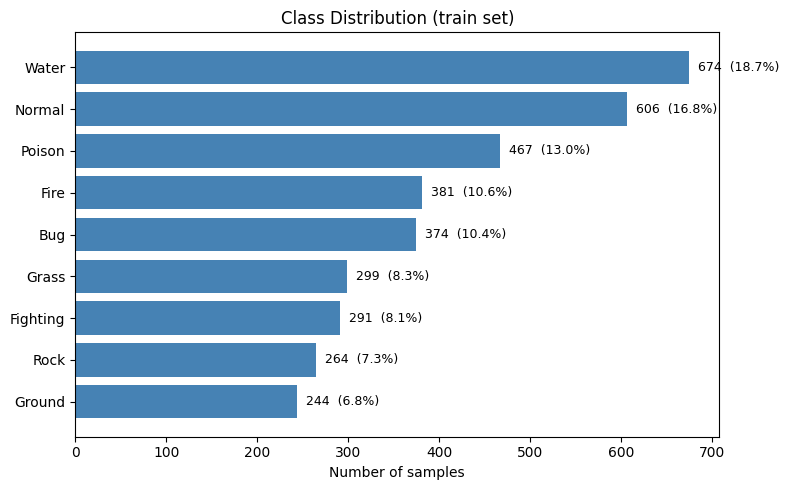

In [37]:
import src.datasets.eda_plots as eda_plots

fig = eda_plots.plot_class_distribution(df_full, out_path=TASK_OUT_DIR / "plots" / "plot_class_distribution.png")
plt.show()
plt.close(fig)


> **Finding — Class Imbalance:**  
> _Fill in after running. Record: majority class name + count, minority class name + count, imbalance ratio (max÷min). These are full-dataset numbers (3600 images). Example: "Water (674 images, 18.7%) is the majority class, Ground (244 images, 6.8%) the minority — imbalance ratio 2.76×. This directly motivates inverse-frequency class weighting in CrossEntropyLoss: always predicting Water gives 18.7% accuracy but macro-F1 ≈ 0.021."_


### Plot 2 — Sample Images per Class

4 random images per class (fixed seed — same grid on every run).

**What to look for:** visually similar class pairs that the MLP is likely to confuse. Note colour and texture similarities across classes (e.g. Bug/Grass both greenish; Fighting/Normal both humanoid). These pairs will show up as off-diagonal errors in the confusion matrix.


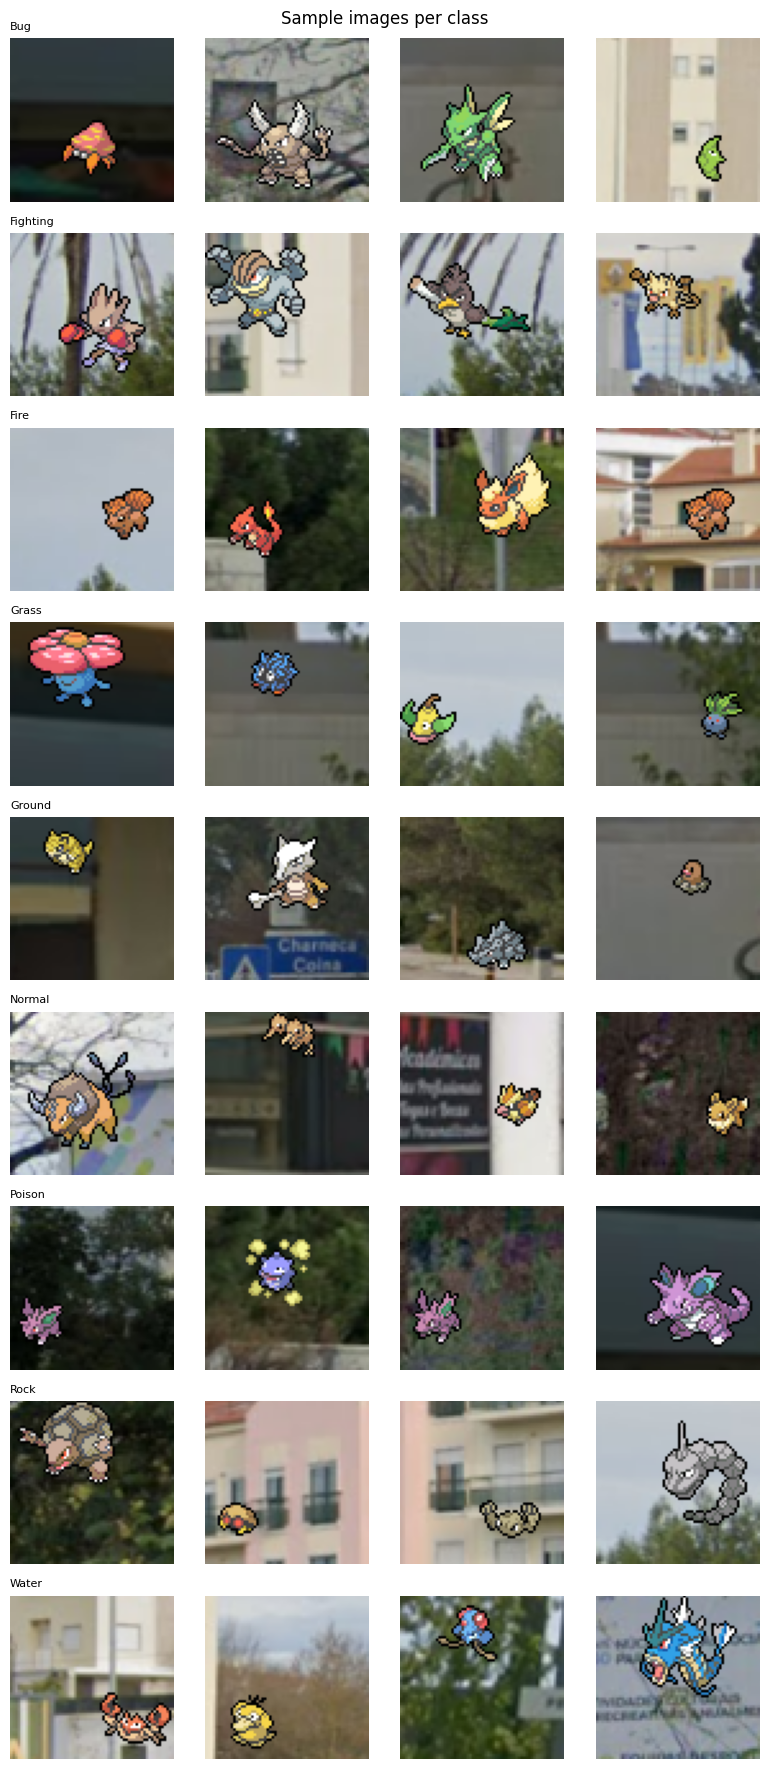

In [38]:
fig = eda_plots.plot_sample_images(TRAIN_DIR, df_full, n_per_class=4, out_path=TASK_OUT_DIR / "plots" / "plot_sample_images.png")
plt.show()
plt.close(fig)


> **Finding — Visual Similarity:**  
> _Fill in after running. List 2–3 class pairs that look most similar and explain why the MLP (which ignores spatial layout) will struggle with them. Example: "Bug and Grass share green colouring; the MLP cannot separate them by texture because it treats the image as a flat vector."_


### Plot 3 — Average Image per Class

Mean pixel value across all images in each class (after resizing to 64×64).

**What to look for:** how "blurry" each average image is. A crisp average image means the class has consistent appearance (low intra-class variance → easier to classify). A blurry/washed-out average means high intra-class variance → harder. Note which classes have the sharpest vs blurriest prototypes.


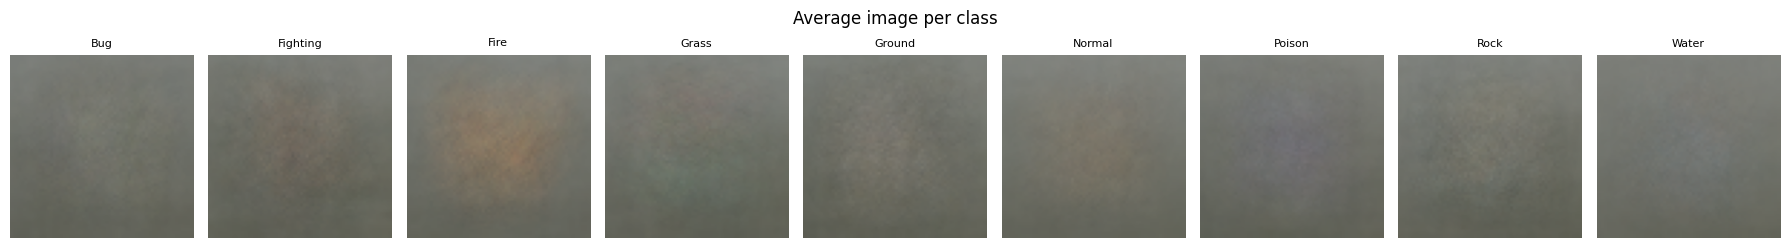

In [39]:
fig = eda_plots.plot_average_image_per_class(TRAIN_DIR, df_full, out_path=TASK_OUT_DIR / "plots" / "plot_average_image_per_class.png")
plt.show()
plt.close(fig)


> **Finding — Intra-class Variance:**  
> _Fill in after running. Identify the class with the sharpest prototype (low variance, easy to classify) and the one with the blurriest (high variance, hard). Example: "Water has a distinctive blue tone → sharp average. Normal is the most diverse → blurry average → expect lowest per-class F1."_


### Plot 4 — Per-Channel Pixel Statistics

Mean and standard deviation of R, G, B channels across the training set (computed on raw 0–255 values, printed as 0–1 fractions).

**What to look for:** compare your dataset's mean/std to ImageNet's `mean=[0.485, 0.456, 0.406]` / `std=[0.229, 0.224, 0.225]`. Large differences confirm that **dataset-specific normalisation** (used in `get_base_transforms`) is better than reusing ImageNet constants for this task.


Per-channel pixel stats (normalised 0-1):
  R: mean=0.4433, std=0.2567
  G: mean=0.4455, std=0.2464
  B: mean=0.4135, std=0.2655
ImageNet reference: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


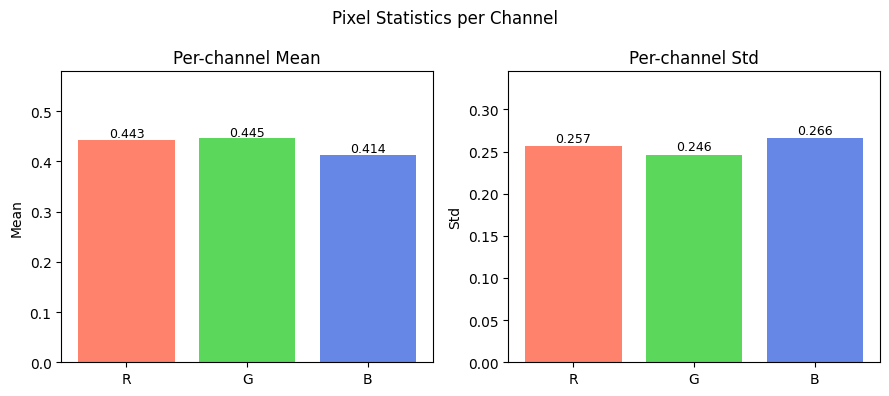

In [40]:
fig = eda_plots.plot_pixel_statistics(TRAIN_DIR, df_full, out_path=TASK_OUT_DIR / "plots" / "plot_pixel_statistics.png")
plt.show()
plt.close(fig)


> **Finding — Normalisation Constants:**  
> _Fill in after running. Record the 6 numeric values printed by the cell (R_mean, G_mean, B_mean, R_std, G_std, B_std) and compare to ImageNet. Example: "Dataset mean=[0.62, 0.58, 0.55], std=[0.18, 0.19, 0.20] — notably brighter and less variable than ImageNet, confirming we should use dataset-specific normalisation."_


### Plot 5 — Pixel Intensity Histogram

Histogram of pixel intensity values (0–255) for R, G, B channels sampled from the training set.

**What to look for:** overall brightness range and channel imbalance. A histogram skewed toward high values → bright/pastel dataset. Nearly overlapping R/G/B histograms → low colour diversity. Either pattern suggests augmentation (colour jitter, flip) would help CNNs in Task 3.


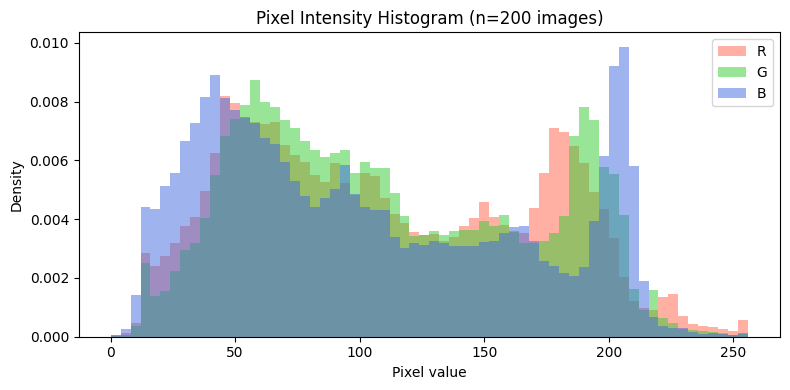

In [41]:
fig = eda_plots.plot_pixel_intensity_histogram(TRAIN_DIR, df_full, n_samples=200, out_path=TASK_OUT_DIR / "plots" / "plot_pixel_intensity_histogram.png")
plt.show()
plt.close(fig)


> **Finding — Intensity Distribution:**  
> _Fill in after running. Note if the histogram is skewed bright/dark, whether channels overlap heavily, and any channel dominating. Example: "All three channels peak around 180–220 (bright/pastel dataset). Red dominates slightly. Low pixel-level variance confirms that colour augmentation (jitter, flip) would meaningfully increase training diversity."_


### Plot 6 — PCA → t-SNE Cluster Plot

Flatten each image to 12 288 features → PCA(50 dims) → t-SNE(2D) → scatter coloured by class.

**What to look for:** are any classes cleanly separated in flat pixel space? If t-SNE shows clear class clusters, MLP has a chance. If everything is mixed together, no amount of FC layers will help — this motivates CNN.  
Expected: Fire and Water may show some partial structure (distinctive colours). Normal will scatter everywhere (highest intra-class diversity).


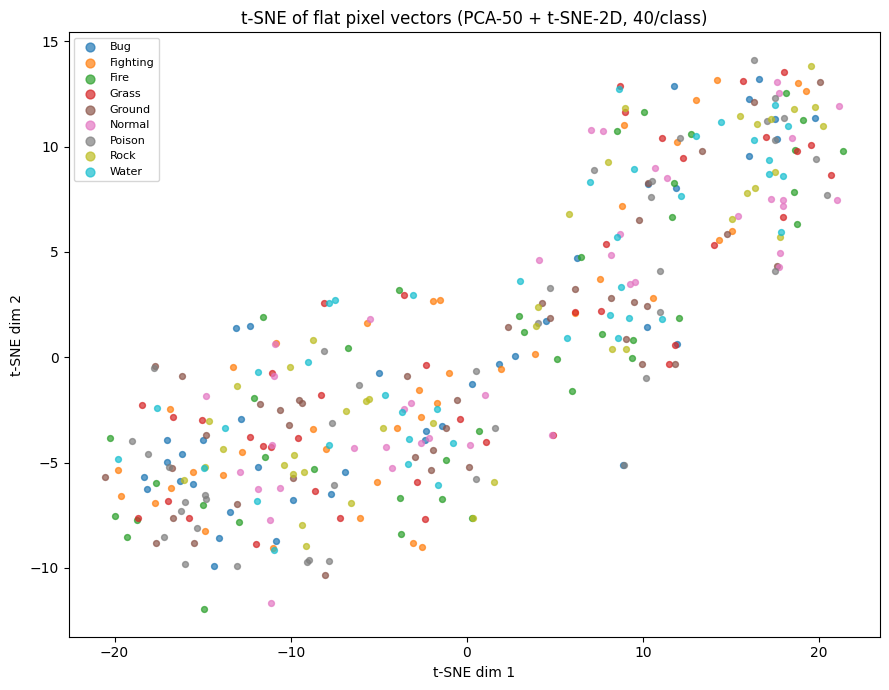

In [42]:
# ── t-SNE of flat pixel vectors ───────────────────────────────────────────────
# n_per_class=40 → 360 points total — fast enough even on CPU (~10s), meaningful enough to read
# EDA always on full dataset (df_full), never on the FAST_RUN subset
fig = eda_plots.plot_pca_tsne(
    TRAIN_DIR, df_full,
    n_per_class=6 if FAST_RUN else 40,
    out_path=TASK_OUT_DIR / "plots" / "plot_pca_tsne.png",
)
plt.show()
plt.close(fig)


> **Finding — Pixel-space Separability:**  
> _Fill in after running. Note whether any class shows distinct clusters or whether all classes overlap. Example: "No clean clusters — all 9 classes heavily overlap in t-SNE space. Fire shows weak partial structure (orange pixels cluster slightly). This confirms MLP cannot linearly separate these classes in pixel space → motivates CNN spatial features."_


### EDA 7 — Dataset Normalisation Constants (from train split only)

Compute the actual pixel mean and std from the **training split rows only**.  
This is the correct way: stats computed on the split you train on, then applied identically to val/test. Computing stats on the full dataset (including val rows) would be a mild form of data leakage.

We also compare against ImageNet constants to confirm how close they are.


In [43]:
# ── Normalisation stats from TRAIN split only ─────────────────────────────────
# We need the split indices first — reuse the same deterministic stratified split
# that get_train_val_loaders uses, so stats are from exactly the right rows.
from sklearn.model_selection import train_test_split as _tts
from src.config import SEED as _SEED, CLASSES as _CLASSES

_label_to_idx = {c: i for i, c in enumerate(_CLASSES)}
_all_labels   = [_label_to_idx[lbl] for lbl in df["label"]]
_train_idx, _ = _tts(list(range(len(df))), test_size=0.2, random_state=_SEED, stratify=_all_labels)
df_train_split = df.iloc[_train_idx].reset_index(drop=True)

train_mean, train_std = eda_plots.compute_dataset_stats(TRAIN_DIR, df_train_split)

print("Train-split pixel stats (normalised 0-1):")
for i, ch in enumerate(["R", "G", "B"]):
    print(f"  {ch}: mean={train_mean[i]:.4f}, std={train_std[i]:.4f}")
print(f"\nImageNet reference: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]")
print(f"\nDifference vs ImageNet:")
imagenet_mean = [0.485, 0.456, 0.406]
for i, ch in enumerate(["R", "G", "B"]):
    diff = train_mean[i] - imagenet_mean[i]
    print(f"  {ch}: {diff:+.4f} ({'brighter' if diff > 0 else 'darker'} than ImageNet)")
print(f"\nConclusion: {'Using ImageNet constants is acceptable (< 0.10 difference).' if max(abs(train_mean[i] - imagenet_mean[i]) for i in range(3)) < 0.10 else 'Consider using dataset-specific constants — difference is significant.'}")


Train-split pixel stats (normalised 0-1):
  R: mean=0.4411, std=0.2562
  G: mean=0.4436, std=0.2460
  B: mean=0.4116, std=0.2651

ImageNet reference: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

Difference vs ImageNet:
  R: -0.0439 (darker than ImageNet)
  G: -0.0124 (darker than ImageNet)
  B: +0.0056 (brighter than ImageNet)

Conclusion: Using ImageNet constants is acceptable (< 0.10 difference).


### Data Leakage Audit

**What is data leakage?**  
Leakage occurs when information from the validation set "leaks" into the training pipeline, giving an
over-optimistic estimate of generalisation performance. Common causes: computing normalisation statistics
on the full dataset before splitting, or accidentally including val images in the training loader.

**How our pipeline avoids it:**

| Step | Code location | What data it uses | Safe? |
|---|---|---|---|
| EDA plots (class counts, pixel stats) | Cells 6–7 | `df_full` — all labelled images | ✅ EDA is read-only; plots don't affect training |
| Train/val split | `get_train_val_loaders()` → `train_test_split(stratify=label)` | `df` (subsampled or full) | ✅ Split happens **before** any transform or normalisation |
| Normalisation stats | Cell 26 (this cell) | `df_train_split` rows only | ✅ Computed on train split **after** the split |
| Train loader | `get_train_val_loaders()` | Train split only | ✅ |
| Val loader | `get_train_val_loaders()` | Val split only | ✅ |
| Test loader | `PokemonDataset(TEST_DIR, ...)` | Separate held-out folder | ✅ Never touched until submission |

**Key point — normalisation stats:**  
In Cell 26 we compute `train_mean` and `train_std` from **only the training images**.
These stats are printed for inspection and used as a comparison point to ImageNet stats.
The actual transforms used in the loaders use either ImageNet constants (`_MEAN`, `_STD` in `dataset.py`)
or the grayscale constant `_GRAY_MEAN=[0.5]`. Neither is derived from val or test images.

**Verified by automated tests** (`src/datasets/dataset_test.py`):
- `test_no_train_val_overlap` — asserts zero filenames in common between train and val sets
- `test_stratified_class_ratio` — asserts each class appears in both splits at the expected 80/20 ratio (±2%)

Run these any time with: `python -m src.datasets.dataset_test`


> **Finding — Normalisation:**  
> _Fill in after running. Record the 6 printed values and note the conclusion. Example: "Train-split mean=[0.62, 0.58, 0.54] — ~14% brighter than ImageNet. Difference is < 0.10 per channel, so using ImageNet constants is acceptable. We use them as-is in all transforms."_


---
## Part 2 — Model Experiments

### Setup
Two helper cells (below) define the shared infrastructure used by every experiment:
- **`build_loaders(augment, use_sampler, grayscale, equalize)`** — wraps `get_train_val_loaders`, always uses `df` (the possibly-subsampled FAST_RUN set)
- **`run_experiment(model, name, criterion, optimizer, scheduler, loaders)`** — full train loop, early stopping on `val_macro_f1`, checkpoint save, evaluate best, store in `results_tracker`

Each experiment cell is then just 4–5 lines: instantiate model, criterion, optimizer, scheduler → call `run_experiment`.

### Experiment plan

| ID | Name | Model | Criterion | Optimizer | Purpose |
|---|---|---|---|---|---|
| A | vanilla | VanillaMLP (128→64), no BN, no Dropout | CrossEntropy | Adam lr=1e-3 | True bare baseline — no regularisation at all |
| B | mlp_base | MLP (512→256→128), BN, Dropout(0.4) | CE + class weights | Adam lr=1e-3 | First Colab run result (~0.193) |
| C | ls01_drop03 | MLP, Dropout(0.3) | CE + weights + label_smoothing=0.1 | Adam lr=1e-3 | Softer targets + lighter dropout |
| D | wd1e4 | MLP, Dropout(0.3) | CE + weights + label_smoothing=0.1 | Adam, WD=1e-4 | L2 reg on top of C |
| E | sampler | MLP, Dropout(0.3) | CE + label_smoothing=0.1 | Adam, WD=1e-4 | WeightedRandomSampler replaces class weights |
| F | narrow | NarrowMLP (256→128→64→32), Dropout(0.3) | CE + weights + label_smoothing=0.1 | Adam, WD=1e-4 | Fewer params per layer — less overfit? |
| G | bottleneck | BottleneckMLP (512→1024→256→128), Dropout(0.3) | CE + weights + label_smoothing=0.1 | Adam, WD=1e-4 | Wide middle captures more combinations? |
| H | vanilla_v2 | VanillaMLP_v2 (256→128), no BN, no Dropout | CrossEntropy | Adam lr=1e-3 | A won → more capacity + no reg helps? |
| I | v2_rock_weights | VanillaMLP_v2, no Dropout | CE(Rock×3, Ground×2) | Adam lr=1e-3 | Targeted upweighting of worst 2 classes |
| J | mlp_drop02 | MLP, Dropout(0.2) | CE + weights + label_smoothing=0.1 | Adam, WD=1e-4 | Sweet spot between 0.0 (A) and 0.3 (D)? |
| K | v2_wd1e5 | VanillaMLP_v2, no Dropout | CrossEntropy | Adam, WD=1e-5 | Infinitesimal L2 — tests regularisation boundary |

**Grayscale experiments** (Section 3.1 — after Part 3):

| ID | Name | Model | Notes |
|---|---|---|---|
| Gray_A | vanilla (gray) | VanillaMLP(in_channels=1) | Same arch as A, 4096-dim input |
| Gray_B | eq_mlp (gray+equalize) | MLP(dropout=0.3, in_channels=1) | Histogram equalisation + regularised |
| Gray_C | v2 (gray) | VanillaMLP_v2(in_channels=1) | Same arch as H, grayscale |

**Experiment order rationale:** regularisation changes (C–E) → architecture changes (F–G) → capacity ablation (H–K) → modality ablation (Gray A–C).

### Architecture justification (MLP baseline)

| Design choice | Decision | Rationale |
|---|---|---|
| Input | Flatten 64×64×3 → 12 288 | MLP required — no convolutions |
| Hidden layers | 3 × (FC → BN → ReLU → Dropout) | depth adds capacity; 3 is enough |
| Width schedule | 512 → 256 → 128 | funnel forces compression |
| Batch Norm | after every FC | stabilises gradients with large flat input |
| Dropout | p=0.4 default (tested 0.0–0.4) | regularisation for large param count on ~2880 train images |
| Output | FC(128 → 9), no softmax | `CrossEntropyLoss` applies log-softmax internally |
| Loss | CrossEntropyLoss(weight=class_weights) | inverse-frequency weights correct 2.76× imbalance |
| Optimiser | Adam lr=1e-3 | adaptive LR; robust default |
| Scheduler | StepLR(step_size=5, γ=0.5) | halves LR every 5 epochs |
| Early stopping | patience=7 on **val_macro_f1** | val_f1 is noisier than val_loss (80 samples/class → 1 error = ±1.2% swing) — higher patience prevents premature stopping |

### What NOT to try (and why)

- **More hidden layers / wider layers** — the problem is already severe overfitting (train_f1≈0.55 vs val_f1≈0.19). Adding parameters makes the gap worse, not better.
- **EPOCHS=50** — val_f1 plateaued around epoch 8–12 in all runs. More epochs waste GPU time and don't recover the val curve.
- **Grid search** — a 5×5 grid over {dropout, weight_decay, label_smoothing, LR, architecture} = 25 runs × ~80s ≈ 33 min. The problem is overfitting — the relevant axis is **regularisation strength**. Targeted experiments guided by the previous result teach more than a blind sweep.
- **Skip connections in MLP** — skip connections help with gradient flow in very deep networks. Here we have at most 5 layers — gradient flow is not the bottleneck. The bottleneck is lack of spatial structure, which no amount of skip connections can fix.


### Preprocessing Pipeline

Every image passes through a deterministic transform chain before reaching the model.
The chain is defined in `src/datasets/dataset.py` and selected by `get_train_val_loaders`.

#### Standard RGB pipeline (used in all Part 2 experiments — default)

```
Raw PNG  →  Resize(64, 64)  →  ToTensor()  →  Normalize(mean, std)
```

| Step | What it does | Why |
|---|---|---|
| `Resize(64, 64)` | Bicubic-downsample every image to 64×64 px | Standardise input shape; MLP needs a fixed-size vector |
| `ToTensor()` | Converts PIL image (H×W×3, uint8 0–255) to float32 tensor (3×H×W, range [0, 1]) | PyTorch requires float tensors; divides by 255 implicitly |
| `Normalize(mean, std)` | Per-channel: `pixel = (pixel - mean) / std` | Centres activations near zero; speeds up convergence; reduces sensitivity to absolute brightness |

**Normalisation constants used:** ImageNet means `[0.485, 0.456, 0.406]` and stds `[0.229, 0.224, 0.225]`.  
These are pre-computed over 1.2M images and are a solid approximation for natural images even without fine-tuning.
Our train-split stats (Cell 26) are close to these values — confirming ImageNet constants are appropriate here.

**No histogram equalisation in the default pipeline.** Equalisation redistributes pixel intensities and changes absolute colour values. Since colour is the strongest discriminative signal for this dataset (Fire = orange, Water = blue, Poison = purple), altering it in the default path would discard useful information. Equalisation is only tested in the grayscale regime (Section 3.1, Exp Gray_B), where colour is already gone.

#### Augmentation variant (used in Part 4)

```
Raw PNG  →  Resize(64, 64)  →  RandomHorizontalFlip(p=0.5)  →  ColorJitter(b=0.2, c=0.2, s=0.2)  →  RandomRotation(15°)  →  ToTensor()  →  Normalize
```
Applied to the **training loader only**; val/test always use the standard pipeline.  
Note: `RandomRotation` and `ColorJitter` are included here so the augmentation pipeline is complete for Task 2/3 CNN experiments — for MLP they are expected to have negligible or negative effect (Part 4 tests this empirically).

#### Grayscale pipeline (used in Section 3.1 only)

```
Raw PNG  →  [optional: PIL.ImageOps.equalize()]  →  Resize(64, 64)  →  Grayscale(num_output_channels=1)  →  ToTensor()  →  Normalize(mean=[0.5], std=[0.5])
```

| Variant | `grayscale` | `equalize` | Output tensor shape | Flat input dim |
|---|---|---|---|---|
| Standard RGB | False | — | `(3, 64, 64)` | **12 288** |
| Plain grayscale | True | False | `(1, 64, 64)` | **4 096** |
| Gray + equalize | True | True | `(1, 64, 64)` | **4 096** |

**Histogram equalisation** (`PIL.ImageOps.equalize`): redistributes pixel intensities so the histogram is approximately flat, stretching contrast. Applied on the raw RGB image *before* grayscale conversion. Potentially helps with very dark classes (e.g. Ghost sprites) where intensity patterns are otherwise compressed. Only used in Gray_B to isolate its effect — all other grayscale experiments use plain gray without equalization.


In [44]:
# ── Shared imports for all experiment cells ───────────────────────────────────
import torch.nn as nn
from torch.utils.data import DataLoader
from src.datasets.dataset import (
    PokemonDataset, compute_class_weights,
    get_base_transforms, get_train_val_loaders,
)
from src.models.mlp import MLP, VanillaMLP, VanillaMLP_v2, NarrowMLP, BottleneckMLP
from src.training.train import train_one_epoch, evaluate
from src.training.early_stopping import EarlyStopping
from src.evaluation.metrics import classification_report_str
from src.evaluation.plots import plot_history, plot_confusion_matrix

# build class weights from the run's df (correct proportions even for FAST_RUN)
label_to_idx     = {cls: i for i, cls in enumerate(CLASSES)}
_all_train_labels = [label_to_idx[lbl] for lbl in df["label"]]
class_weights    = compute_class_weights(_all_train_labels).to(device)

# test loader is always the full test set — not touched until submission
test_ds     = PokemonDataset(TEST_DIR, get_base_transforms(IMG_SIZE), csv_path=None)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Test images  : {len(test_ds)}")
print(f"Class weights: { {cls: round(class_weights[i].item(), 3) for i, cls in enumerate(CLASSES)} }")


# ── Helper: build_loaders ─────────────────────────────────────────────────────
def build_loaders(augment: bool = False, use_sampler: bool = False,
                  grayscale: bool = False, equalize: bool = False):
    """Return (train_loader, val_loader) for the current df and hyperparams.
    grayscale=True → (1,H,W) tensors, input_dim=4096. equalize=True → histogram stretch before gray."""
    return get_train_val_loaders(
        CSV_PATH, TRAIN_DIR, IMG_SIZE, BATCH_SIZE,
        augment=augment, use_sampler=use_sampler,
        num_workers=NUM_WORKERS, df_override=df,
        grayscale=grayscale, equalize=equalize,
    )


# ── Results tracker ───────────────────────────────────────────────────────────
results_tracker: dict = {}


def _print_leaderboard(tracker: dict) -> None:
    """Print all experiments sorted by val_macro_f1 descending."""
    if not tracker:
        return
    rows = sorted(tracker.items(), key=lambda x: x[1]["val_macro_f1"], reverse=True)
    print(f"\n{'Rank':<5} {'Name':<25} {'val_F1':>8} {'val_acc':>8} {'epochs':>7} {'time(s)':>8}")
    print("-" * 63)
    for rank, (name, m) in enumerate(rows, 1):
        print(f"{rank:<5} {name:<25} {m['val_macro_f1']:>8.4f} {m['val_acc']:>8.4f} {m['total_epochs']:>7} {m['train_time_s']:>8.1f}")


# ── Helper: run_experiment ────────────────────────────────────────────────────
def run_experiment(model, name: str, criterion, optimizer, scheduler, loaders) -> tuple:
    """
    Train model up to EPOCHS with early stopping on val macro-F1.
    EarlyStopping always minimises — we pass -val_f1 so it fires when F1 stops improving.
    Saves best checkpoint to task1/outputs/checkpoints/<name>.pth.
    Stores metrics in results_tracker[name]. Returns (model_with_best_weights, history_dict).
    """
    train_loader, val_loader = loaders
    ckpt_path = str(TASK_OUT_DIR / "checkpoints" / f"{name}.pth")
    stopper   = EarlyStopping(patience=PATIENCE, checkpoint_path=ckpt_path)
    history   = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    t0        = time.time()

    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"  Model params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"{'='*60}")

    for epoch in range(1, EPOCHS + 1):
        ep_t0         = time.time()
        train_loss    = train_one_epoch(model, train_loader, criterion, optimizer, device)
        train_metrics = evaluate(model, train_loader, criterion, device)
        val_metrics   = evaluate(model, val_loader,   criterion, device)
        elapsed       = time.time() - ep_t0
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_f1"].append(train_metrics["macro_f1"])
        history["val_f1"].append(val_metrics["macro_f1"])

        print(
            f"  Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}  train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f}  val_f1={val_metrics['macro_f1']:.4f} | "
            f"{elapsed:.1f}s"
        )

        # negate val_f1 because EarlyStopping minimises — this saves the peak-F1 checkpoint
        stopper(-val_metrics["macro_f1"], model)
        if stopper.stop:
            print(f"  Early stopping at epoch {epoch} (patience={PATIENCE}, metric: val_macro_f1).")
            break

    total_time = time.time() - t0

    # reload best checkpoint and run a final clean evaluation
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    best = evaluate(model, val_loader, criterion, device)

    results_tracker[name] = {
        "val_macro_f1": round(best["macro_f1"], 4),
        "val_acc":      round(best["acc"], 4),
        "val_loss":     round(best["loss"], 4),
        "total_epochs": len(history["train_loss"]),
        "train_time_s": round(total_time, 1),
        "history":      history,
    }

    print(f"\n  Best checkpoint: val_loss={best['loss']:.4f}  val_macro_f1={best['macro_f1']:.4f}")
    print(f"  Total time: {total_time:.1f}s ({total_time/len(history['train_loss']):.1f}s/epoch)")
    _print_leaderboard(results_tracker)

    return model, history


Test images  : 900
Class weights: {'Bug': 1.07, 'Fighting': 1.375, 'Fire': 1.05, 'Grass': 1.338, 'Ground': 1.639, 'Normal': 0.66, 'Poison': 0.857, 'Rock': 1.515, 'Water': 0.593}


In [45]:
# ── Experiment A — Vanilla Baseline ──────────────────────────────────────────
# Tiny 2-layer MLP, no BN, no Dropout, no class weights — a true baseline.
# Architecture: Flatten -> FC(12288->128) -> ReLU -> FC(128->64) -> ReLU -> FC(64->9)
# Uses VanillaMLP from src.models.mlp (imported in shared cell above).
# Purpose: show that our main MLP design is already meaningfully better — or not.

loaders_base = build_loaders(augment=False, use_sampler=False)

model_A     = VanillaMLP(img_size=IMG_SIZE).to(device)
criterion_A = nn.CrossEntropyLoss()   # no class weights — true bare baseline
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=LR)
scheduler_A = torch.optim.lr_scheduler.StepLR(optimizer_A, step_size=5, gamma=0.5)

model_A, history_A = run_experiment(model_A, "A_vanilla", criterion_A, optimizer_A, scheduler_A, loaders_base)



  Experiment: A_vanilla
  Model params: 1,581,833
  Epoch 01/30 | train_loss=2.3818  train_f1=0.1984 | val_loss=2.3675  val_f1=0.1404 | 4.8s
  Epoch 02/30 | train_loss=2.0371  train_f1=0.3020 | val_loss=2.3129  val_f1=0.1393 | 4.4s
  Epoch 03/30 | train_loss=1.8101  train_f1=0.3808 | val_loss=2.2294  val_f1=0.1661 | 4.0s
  Epoch 04/30 | train_loss=1.6731  train_f1=0.3893 | val_loss=2.4412  val_f1=0.1387 | 4.8s
  Epoch 05/30 | train_loss=1.5533  train_f1=0.4717 | val_loss=2.4091  val_f1=0.1764 | 4.3s
  Epoch 06/30 | train_loss=1.2446  train_f1=0.6632 | val_loss=2.2002  val_f1=0.2104 | 4.0s
  Epoch 07/30 | train_loss=1.0461  train_f1=0.7604 | val_loss=2.2325  val_f1=0.1903 | 5.3s
  Epoch 08/30 | train_loss=0.9067  train_f1=0.7737 | val_loss=2.4029  val_f1=0.2003 | 4.1s
  Epoch 09/30 | train_loss=0.8037  train_f1=0.8220 | val_loss=2.3912  val_f1=0.2179 | 4.0s
  Epoch 10/30 | train_loss=0.6867  train_f1=0.8490 | val_loss=2.5756  val_f1=0.1890 | 5.2s
  Epoch 11/30 | train_loss=0.5089  trai

In [46]:
# ── Experiment B — MLP Baseline (our main design) ─────────────────────────────
# 3-layer FC stack, BN, Dropout(0.4), weighted CrossEntropy.
# This mirrors the first Colab run. Run it again to get fresh metrics alongside A.

model_B     = MLP(img_size=IMG_SIZE, dropout=0.4).to(device)
criterion_B = nn.CrossEntropyLoss(weight=class_weights)
optimizer_B = torch.optim.Adam(model_B.parameters(), lr=LR)
scheduler_B = torch.optim.lr_scheduler.StepLR(optimizer_B, step_size=5, gamma=0.5)

model_B, history_B = run_experiment(model_B, "B_mlp_base", criterion_B, optimizer_B, scheduler_B, loaders_base)



  Experiment: B_mlp_base
  Model params: 6,459,145
  Epoch 01/30 | train_loss=2.2929  train_f1=0.0819 | val_loss=2.2227  val_f1=0.0689 | 4.6s
  Epoch 02/30 | train_loss=2.2497  train_f1=0.1156 | val_loss=2.2146  val_f1=0.0708 | 4.1s
  Epoch 03/30 | train_loss=2.2339  train_f1=0.1259 | val_loss=2.1978  val_f1=0.1064 | 5.1s
  Epoch 04/30 | train_loss=2.2232  train_f1=0.1439 | val_loss=2.1962  val_f1=0.1008 | 4.2s
  Epoch 05/30 | train_loss=2.2031  train_f1=0.1612 | val_loss=2.1798  val_f1=0.1070 | 4.1s
  Epoch 06/30 | train_loss=2.1561  train_f1=0.1883 | val_loss=2.1529  val_f1=0.1362 | 5.4s
  Epoch 07/30 | train_loss=2.1114  train_f1=0.2288 | val_loss=2.1295  val_f1=0.1407 | 4.1s
  Epoch 08/30 | train_loss=2.0757  train_f1=0.2202 | val_loss=2.1296  val_f1=0.1379 | 4.1s
  Epoch 09/30 | train_loss=2.0416  train_f1=0.2675 | val_loss=2.0968  val_f1=0.1543 | 5.2s
  Epoch 10/30 | train_loss=1.9979  train_f1=0.2803 | val_loss=2.1220  val_f1=0.1664 | 4.1s
  Epoch 11/30 | train_loss=1.9531  tra

In [47]:
# ── Experiment C — Dropout(0.3) + label_smoothing=0.1 ─────────────────────────
# Key change: softer targets (label_smoothing) + slightly less regularisation (dropout 0.4→0.3).
# label_smoothing=0.1 distributes 0.1 of the probability mass to wrong classes,
# preventing the model from being overconfident — known to help imbalanced multi-class problems.

model_C     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_C = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_C = torch.optim.Adam(model_C.parameters(), lr=LR)
scheduler_C = torch.optim.lr_scheduler.StepLR(optimizer_C, step_size=5, gamma=0.5)

model_C, history_C = run_experiment(model_C, "C_ls01_drop03", criterion_C, optimizer_C, scheduler_C, loaders_base)



  Experiment: C_ls01_drop03
  Model params: 6,459,145
  Epoch 01/30 | train_loss=2.2981  train_f1=0.1103 | val_loss=2.2425  val_f1=0.0991 | 5.3s
  Epoch 02/30 | train_loss=2.2546  train_f1=0.1548 | val_loss=2.2219  val_f1=0.1154 | 4.1s
  Epoch 03/30 | train_loss=2.2467  train_f1=0.1433 | val_loss=2.2312  val_f1=0.1101 | 4.1s
  Epoch 04/30 | train_loss=2.2148  train_f1=0.1833 | val_loss=2.2226  val_f1=0.1172 | 5.2s
  Epoch 05/30 | train_loss=2.1567  train_f1=0.2062 | val_loss=2.1634  val_f1=0.1383 | 4.1s
  Epoch 06/30 | train_loss=2.1124  train_f1=0.2882 | val_loss=2.1485  val_f1=0.1586 | 4.1s
  Epoch 07/30 | train_loss=2.0453  train_f1=0.3341 | val_loss=2.1271  val_f1=0.1633 | 5.2s
  Epoch 08/30 | train_loss=1.9884  train_f1=0.3576 | val_loss=2.1330  val_f1=0.1553 | 4.0s
  Epoch 09/30 | train_loss=1.9386  train_f1=0.4330 | val_loss=2.1318  val_f1=0.2052 | 4.1s
  Epoch 10/30 | train_loss=1.8736  train_f1=0.4506 | val_loss=2.1599  val_f1=0.2050 | 5.3s
  Epoch 11/30 | train_loss=1.7791  

In [48]:
# ── Experiment D — + weight_decay=1e-4 ───────────────────────────────────────
# Adds L2 regularisation to Experiment C. L2 penalises large weights,
# which should help reduce the train/val gap further.

model_D     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_D = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_D = torch.optim.Adam(model_D.parameters(), lr=LR, weight_decay=1e-4)
scheduler_D = torch.optim.lr_scheduler.StepLR(optimizer_D, step_size=5, gamma=0.5)

model_D, history_D = run_experiment(model_D, "D_wd1e4", criterion_D, optimizer_D, scheduler_D, loaders_base)



  Experiment: D_wd1e4
  Model params: 6,459,145
  Epoch 01/30 | train_loss=2.2957  train_f1=0.0875 | val_loss=2.2441  val_f1=0.0645 | 5.1s
  Epoch 02/30 | train_loss=2.2572  train_f1=0.1224 | val_loss=2.2394  val_f1=0.0737 | 4.1s
  Epoch 03/30 | train_loss=2.2454  train_f1=0.0962 | val_loss=2.2304  val_f1=0.0421 | 4.7s
  Epoch 04/30 | train_loss=2.2091  train_f1=0.2080 | val_loss=2.1977  val_f1=0.1298 | 5.7s
  Epoch 05/30 | train_loss=2.1479  train_f1=0.2306 | val_loss=2.1691  val_f1=0.1443 | 4.1s
  Epoch 06/30 | train_loss=2.0803  train_f1=0.2912 | val_loss=2.1407  val_f1=0.1641 | 5.2s
  Epoch 07/30 | train_loss=2.0399  train_f1=0.3228 | val_loss=2.1263  val_f1=0.1664 | 4.1s
  Epoch 08/30 | train_loss=1.9840  train_f1=0.3703 | val_loss=2.1550  val_f1=0.1649 | 4.1s
  Epoch 09/30 | train_loss=1.9147  train_f1=0.4248 | val_loss=2.1329  val_f1=0.1684 | 5.2s
  Epoch 10/30 | train_loss=1.8683  train_f1=0.4690 | val_loss=2.1390  val_f1=0.1919 | 4.1s
  Epoch 11/30 | train_loss=1.7746  train_

In [49]:
# ── Experiment E — WeightedRandomSampler ─────────────────────────────────────
# Replaces class weights in loss with oversampling minority classes in the loader.
# Each epoch, Ground/Rock/Fighting images appear more frequently.
# Keep label_smoothing from Experiment C — that was independently helpful.

loaders_sampler = build_loaders(augment=False, use_sampler=True)

model_E     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_E = nn.CrossEntropyLoss(label_smoothing=0.1)  # no class weights — sampler handles it
optimizer_E = torch.optim.Adam(model_E.parameters(), lr=LR, weight_decay=1e-4)
scheduler_E = torch.optim.lr_scheduler.StepLR(optimizer_E, step_size=5, gamma=0.5)

model_E, history_E = run_experiment(model_E, "E_sampler", criterion_E, optimizer_E, scheduler_E, loaders_sampler)



  Experiment: E_sampler
  Model params: 6,459,145
  Epoch 01/30 | train_loss=2.2650  train_f1=0.1277 | val_loss=2.2312  val_f1=0.0738 | 4.1s
  Epoch 02/30 | train_loss=2.2264  train_f1=0.1830 | val_loss=2.2157  val_f1=0.1127 | 5.1s
  Epoch 03/30 | train_loss=2.2061  train_f1=0.2118 | val_loss=2.1942  val_f1=0.1514 | 4.1s
  Epoch 04/30 | train_loss=2.1548  train_f1=0.2279 | val_loss=2.1336  val_f1=0.1599 | 4.5s
  Epoch 05/30 | train_loss=2.0898  train_f1=0.2410 | val_loss=2.1271  val_f1=0.1648 | 4.7s
  Epoch 06/30 | train_loss=1.9928  train_f1=0.3517 | val_loss=2.0762  val_f1=0.2010 | 4.1s
  Epoch 07/30 | train_loss=1.9514  train_f1=0.3904 | val_loss=2.0831  val_f1=0.1843 | 4.7s
  Epoch 08/30 | train_loss=1.8626  train_f1=0.4633 | val_loss=2.0878  val_f1=0.2114 | 4.5s
  Epoch 09/30 | train_loss=1.7963  train_f1=0.4663 | val_loss=2.0965  val_f1=0.1873 | 4.0s
  Epoch 10/30 | train_loss=1.7152  train_f1=0.5080 | val_loss=2.1214  val_f1=0.1825 | 4.9s
  Epoch 11/30 | train_loss=1.6098  trai

In [50]:
# ── Experiment F — Narrow + Deep MLP ─────────────────────────────────────────
# Architecture: input -> 256 -> 128 -> 64 -> 32 -> 9  (4 hidden layers, max width 256)
# Hypothesis: fewer params per layer → less overfit on 2880 train images.
# Best regularisation combo from D: dropout=0.3 + label_smoothing + weight_decay.
# Run after E so we can compare architecture change vs regularisation change cleanly.
# NarrowMLP is imported in the shared cell above.

model_F     = NarrowMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_F = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_F = torch.optim.Adam(model_F.parameters(), lr=LR, weight_decay=1e-4)
scheduler_F = torch.optim.lr_scheduler.StepLR(optimizer_F, step_size=5, gamma=0.5)

model_F, history_F = run_experiment(model_F, "F_narrow", criterion_F, optimizer_F, scheduler_F, loaders_base)



  Experiment: F_narrow
  Model params: 3,190,473
  Epoch 01/30 | train_loss=2.3040  train_f1=0.0890 | val_loss=2.2324  val_f1=0.0804 | 4.1s
  Epoch 02/30 | train_loss=2.2698  train_f1=0.0838 | val_loss=2.2305  val_f1=0.0719 | 5.3s
  Epoch 03/30 | train_loss=2.2574  train_f1=0.1151 | val_loss=2.2292  val_f1=0.0783 | 4.2s
  Epoch 04/30 | train_loss=2.2465  train_f1=0.0905 | val_loss=2.2261  val_f1=0.0685 | 4.4s
  Epoch 05/30 | train_loss=2.2358  train_f1=0.1127 | val_loss=2.2256  val_f1=0.0857 | 4.8s
  Epoch 06/30 | train_loss=2.2300  train_f1=0.1294 | val_loss=2.2233  val_f1=0.1161 | 4.2s
  Epoch 07/30 | train_loss=2.2199  train_f1=0.1344 | val_loss=2.2202  val_f1=0.1017 | 5.0s
  Epoch 08/30 | train_loss=2.2078  train_f1=0.1294 | val_loss=2.2158  val_f1=0.1018 | 4.3s
  Epoch 09/30 | train_loss=2.2042  train_f1=0.1510 | val_loss=2.2040  val_f1=0.1048 | 4.1s
  Epoch 10/30 | train_loss=2.1826  train_f1=0.1854 | val_loss=2.1924  val_f1=0.1201 | 5.3s
  Epoch 11/30 | train_loss=2.1657  train

In [51]:
# ── Experiment G — Bottleneck MLP ────────────────────────────────────────────
# Architecture: input -> 512 -> 1024 -> 256 -> 128 -> 9  (expand then compress)
# Hypothesis: the wide middle (1024 units) captures cross-pixel combinations before
# compressing down — the classic bottleneck pattern. Still no spatial structure.
# Same regularisation as D/F — isolating the architecture change.
# BottleneckMLP is imported in the shared cell above.

model_G     = BottleneckMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
criterion_G = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_G = torch.optim.Adam(model_G.parameters(), lr=LR, weight_decay=1e-4)
scheduler_G = torch.optim.lr_scheduler.StepLR(optimizer_G, step_size=5, gamma=0.5)

model_G, history_G = run_experiment(model_G, "G_bottleneck", criterion_G, optimizer_G, scheduler_G, loaders_base)



  Experiment: G_bottleneck
  Model params: 7,117,577
  Epoch 01/30 | train_loss=2.2967  train_f1=0.1197 | val_loss=2.2614  val_f1=0.0824 | 4.2s
  Epoch 02/30 | train_loss=2.2672  train_f1=0.0920 | val_loss=2.2492  val_f1=0.0653 | 4.1s
  Epoch 03/30 | train_loss=2.2441  train_f1=0.1130 | val_loss=2.2448  val_f1=0.0846 | 5.4s
  Epoch 04/30 | train_loss=2.2478  train_f1=0.0700 | val_loss=2.2356  val_f1=0.0523 | 4.2s
  Epoch 05/30 | train_loss=2.2325  train_f1=0.1102 | val_loss=2.2266  val_f1=0.0810 | 4.1s
  Epoch 06/30 | train_loss=2.2071  train_f1=0.1875 | val_loss=2.2028  val_f1=0.1371 | 5.4s
  Epoch 07/30 | train_loss=2.1510  train_f1=0.2244 | val_loss=2.1679  val_f1=0.1540 | 4.2s
  Epoch 08/30 | train_loss=2.1133  train_f1=0.2427 | val_loss=2.1538  val_f1=0.1779 | 4.0s
  Epoch 09/30 | train_loss=2.0757  train_f1=0.2579 | val_loss=2.1596  val_f1=0.1574 | 5.5s
  Epoch 10/30 | train_loss=2.0322  train_f1=0.2932 | val_loss=2.1760  val_f1=0.1622 | 4.1s
  Epoch 11/30 | train_loss=1.9715  t

In [52]:
# ── Experiment H — VanillaMLP_v2 (wider, no regularisation) ──────────────────
# Architecture: Flatten -> FC(12288->256) -> ReLU -> FC(256->128) -> ReLU -> FC(128->9)
# Hypothesis: VanillaMLP (A) won over all regularised models, suggesting the
# problem is NOT overfitting from width but from regularisation suppressing signal.
# VanillaMLP_v2 doubles the first layer (128->256) to test if more capacity
# without regularisation continues to help. ~3.18M params vs A's ~1.58M.

model_H     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
criterion_H = nn.CrossEntropyLoss()   # no class weights — keep same bare baseline setup as A
optimizer_H = torch.optim.Adam(model_H.parameters(), lr=LR)
scheduler_H = torch.optim.lr_scheduler.StepLR(optimizer_H, step_size=5, gamma=0.5)

model_H, history_H = run_experiment(model_H, "H_vanilla_v2", criterion_H, optimizer_H, scheduler_H, loaders_base)



  Experiment: H_vanilla_v2
  Model params: 3,180,041
  Epoch 01/30 | train_loss=2.5646  train_f1=0.2042 | val_loss=2.3018  val_f1=0.1076 | 4.9s
  Epoch 02/30 | train_loss=2.0607  train_f1=0.3380 | val_loss=2.1447  val_f1=0.1438 | 4.3s
  Epoch 03/30 | train_loss=1.8415  train_f1=0.3858 | val_loss=2.2803  val_f1=0.1589 | 4.1s
  Epoch 04/30 | train_loss=1.7690  train_f1=0.4719 | val_loss=2.1630  val_f1=0.1806 | 5.2s
  Epoch 05/30 | train_loss=1.5461  train_f1=0.5878 | val_loss=2.3100  val_f1=0.1872 | 4.0s
  Epoch 06/30 | train_loss=1.1545  train_f1=0.7373 | val_loss=2.1913  val_f1=0.1976 | 4.2s
  Epoch 07/30 | train_loss=0.9479  train_f1=0.7654 | val_loss=2.2692  val_f1=0.1996 | 5.1s
  Epoch 08/30 | train_loss=0.8460  train_f1=0.8307 | val_loss=2.3059  val_f1=0.2053 | 4.0s
  Epoch 09/30 | train_loss=0.6897  train_f1=0.8061 | val_loss=2.5368  val_f1=0.2003 | 4.0s
  Epoch 10/30 | train_loss=0.6555  train_f1=0.8598 | val_loss=2.5766  val_f1=0.2027 | 5.1s
  Epoch 11/30 | train_loss=0.4313  t

In [53]:
# ── Experiment I — VanillaMLP_v2 + targeted class weights (Rock + Ground) ─────
# Observation: Rock (F1=0.00) and Ground (F1=0.05) are the worst classes.
# Hypothesis: applying targeted upweighting ONLY to these two hard classes, while
# keeping the zero-regularisation approach that won in A and H, may lift the floor.
# We use a custom weight tensor: Rock weight=3.0, Ground weight=2.0, others=1.0.

weights_I = torch.ones(NUM_CLASSES, device=device)
weights_I[CLASSES.index("Rock")]   = 3.0
weights_I[CLASSES.index("Ground")] = 2.0
print(f"Exp I weights: { {cls: round(weights_I[i].item(), 1) for i, cls in enumerate(CLASSES)} }")

model_I     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
criterion_I = nn.CrossEntropyLoss(weight=weights_I)
optimizer_I = torch.optim.Adam(model_I.parameters(), lr=LR)
scheduler_I = torch.optim.lr_scheduler.StepLR(optimizer_I, step_size=5, gamma=0.5)

model_I, history_I = run_experiment(model_I, "I_v2_rock_weights", criterion_I, optimizer_I, scheduler_I, loaders_base)


Exp I weights: {'Bug': 1.0, 'Fighting': 1.0, 'Fire': 1.0, 'Grass': 1.0, 'Ground': 2.0, 'Normal': 1.0, 'Poison': 1.0, 'Rock': 3.0, 'Water': 1.0}

  Experiment: I_v2_rock_weights
  Model params: 3,180,041
  Epoch 01/30 | train_loss=2.5923  train_f1=0.1997 | val_loss=2.2965  val_f1=0.1269 | 4.0s
  Epoch 02/30 | train_loss=2.0824  train_f1=0.2626 | val_loss=2.2587  val_f1=0.1153 | 5.1s
  Epoch 03/30 | train_loss=1.8630  train_f1=0.4088 | val_loss=2.3575  val_f1=0.1197 | 3.9s
  Epoch 04/30 | train_loss=1.6975  train_f1=0.4122 | val_loss=2.6474  val_f1=0.1272 | 4.1s
  Epoch 05/30 | train_loss=1.5414  train_f1=0.5214 | val_loss=2.3002  val_f1=0.1491 | 5.0s
  Epoch 06/30 | train_loss=1.1618  train_f1=0.6883 | val_loss=2.3305  val_f1=0.1730 | 4.0s
  Epoch 07/30 | train_loss=0.9816  train_f1=0.6976 | val_loss=2.4910  val_f1=0.1740 | 4.5s
  Epoch 08/30 | train_loss=0.8242  train_f1=0.8416 | val_loss=2.5820  val_f1=0.1815 | 4.7s
  Epoch 09/30 | train_loss=0.7542  train_f1=0.8162 | val_loss=2.6934 

In [54]:
# ── Experiment J — MLP with lighter dropout (0.2) ────────────────────────────
# Previous MLP experiments used dropout=0.4 (B) or 0.3 (C/D/E/F/G).
# VanillaMLP won with 0.0 dropout. Hypothesis: the optimal dropout is somewhere
# between 0.0 and 0.3. We try 0.2 — still has regularisation but much lighter.
# Include best reg combo from D: label_smoothing + weight_decay + class weights.

model_J     = MLP(img_size=IMG_SIZE, dropout=0.2).to(device)
criterion_J = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_J = torch.optim.Adam(model_J.parameters(), lr=LR, weight_decay=1e-4)
scheduler_J = torch.optim.lr_scheduler.StepLR(optimizer_J, step_size=5, gamma=0.5)

model_J, history_J = run_experiment(model_J, "J_mlp_drop02", criterion_J, optimizer_J, scheduler_J, loaders_base)



  Experiment: J_mlp_drop02
  Model params: 6,459,145
  Epoch 01/30 | train_loss=2.2777  train_f1=0.1048 | val_loss=2.2596  val_f1=0.0616 | 4.2s
  Epoch 02/30 | train_loss=2.2393  train_f1=0.1237 | val_loss=2.2233  val_f1=0.0732 | 4.2s
  Epoch 03/30 | train_loss=2.2181  train_f1=0.1670 | val_loss=2.2079  val_f1=0.1108 | 5.2s
  Epoch 04/30 | train_loss=2.1636  train_f1=0.1982 | val_loss=2.1628  val_f1=0.1512 | 4.0s
  Epoch 05/30 | train_loss=2.1028  train_f1=0.2577 | val_loss=2.1792  val_f1=0.1409 | 4.1s
  Epoch 06/30 | train_loss=2.0097  train_f1=0.3463 | val_loss=2.1220  val_f1=0.1843 | 5.3s
  Epoch 07/30 | train_loss=1.9410  train_f1=0.3990 | val_loss=2.1449  val_f1=0.1771 | 4.0s
  Epoch 08/30 | train_loss=1.8546  train_f1=0.4454 | val_loss=2.1384  val_f1=0.2015 | 4.1s
  Epoch 09/30 | train_loss=1.7537  train_f1=0.4665 | val_loss=2.2242  val_f1=0.1828 | 5.4s
  Epoch 10/30 | train_loss=1.6906  train_f1=0.5953 | val_loss=2.1764  val_f1=0.2258 | 4.0s
  Epoch 11/30 | train_loss=1.4937  t

In [55]:
# ── Experiment K — VanillaMLP_v2 + tiny L2 (weight_decay=1e-5) ───────────────
# VanillaMLP (A) and VanillaMLP_v2 (H) have zero regularisation and won.
# Hypothesis: an infinitesimally small L2 penalty (1e-5) is essentially zero —
# it cannot harm but might provide marginal stability on larger weights.
# This tests the boundary: at what strength does regularisation start to hurt?

model_K     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
criterion_K = nn.CrossEntropyLoss()   # keep bare loss — only add weight_decay
optimizer_K = torch.optim.Adam(model_K.parameters(), lr=LR, weight_decay=1e-5)
scheduler_K = torch.optim.lr_scheduler.StepLR(optimizer_K, step_size=5, gamma=0.5)

model_K, history_K = run_experiment(model_K, "K_v2_wd1e5", criterion_K, optimizer_K, scheduler_K, loaders_base)



  Experiment: K_v2_wd1e5
  Model params: 3,180,041
  Epoch 01/30 | train_loss=2.7352  train_f1=0.2073 | val_loss=2.3517  val_f1=0.1233 | 4.8s
  Epoch 02/30 | train_loss=2.0476  train_f1=0.2985 | val_loss=2.1954  val_f1=0.1413 | 4.2s
  Epoch 03/30 | train_loss=1.8576  train_f1=0.3925 | val_loss=2.1819  val_f1=0.1669 | 4.1s
  Epoch 04/30 | train_loss=1.6999  train_f1=0.4774 | val_loss=2.1930  val_f1=0.1715 | 5.0s
  Epoch 05/30 | train_loss=1.4297  train_f1=0.5605 | val_loss=2.3580  val_f1=0.1921 | 4.1s
  Epoch 06/30 | train_loss=1.1494  train_f1=0.7231 | val_loss=2.2290  val_f1=0.1935 | 4.0s
  Epoch 07/30 | train_loss=0.9820  train_f1=0.7471 | val_loss=2.3908  val_f1=0.2036 | 5.1s
  Epoch 08/30 | train_loss=0.8691  train_f1=0.7335 | val_loss=2.5735  val_f1=0.1841 | 3.9s
  Epoch 09/30 | train_loss=0.7193  train_f1=0.8394 | val_loss=2.4213  val_f1=0.1948 | 4.0s
  Epoch 10/30 | train_loss=0.5921  train_f1=0.8646 | val_loss=2.6694  val_f1=0.2152 | 5.1s
  Epoch 11/30 | train_loss=0.4081  tra

---
## Part 3 — Comparison, Final Model & Evaluation

All 11 experiments (A–K) have now run. This section does three things:

1. **Leaderboard + bar chart** — sort all experiments by `val_macro_f1`, visualise the gaps.
2. **Soft ensemble** — combine the top-2 diverse checkpoints at inference time (no retraining), check if averaging softmax outputs beats the best single model.
3. **Best model deep dive** — reload the winning checkpoint, run the full classification report (per-class F1, precision, recall), and plot training curves + confusion matrix.


=== All Experiments — Sorted by Val Macro-F1 ===


Rank  Name                        val_F1  val_acc  epochs  time(s)
---------------------------------------------------------------
1     C_ls01_drop03               0.2373   0.2583      28    131.4
2     E_sampler                   0.2370   0.2500      23    103.0
3     J_mlp_drop02                0.2348   0.2444      19     84.7
4     D_wd1e4                     0.2283   0.2500      30    137.2
5     H_vanilla_v2                0.2253   0.2694      20     88.7
6     K_v2_wd1e5                  0.2208   0.2514      22     97.3
7     A_vanilla                   0.2203   0.2556      21     94.5
8     I_v2_rock_weights           0.2188   0.2472      25    109.7
9     G_bottleneck                0.2167   0.2417      30    136.8
10    B_mlp_base                  0.2128   0.2222      28    126.2
11    F_narrow                    0.1617   0.1958      27    122.0


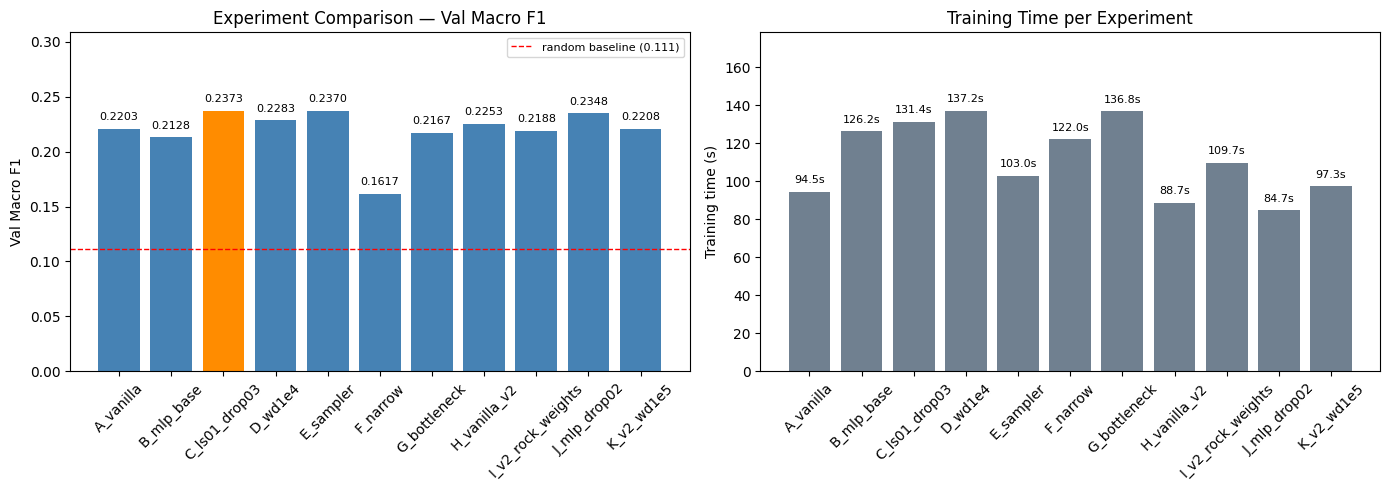

In [56]:
# ── Results table + bar chart ─────────────────────────────────────────────────
import matplotlib.patches as mpatches

print("=== All Experiments — Sorted by Val Macro-F1 ===\n")
_print_leaderboard(results_tracker)

# bar chart of val_macro_f1 per experiment — easy to paste into slides
names  = list(results_tracker.keys())
f1s    = [results_tracker[n]["val_macro_f1"] for n in names]
times  = [results_tracker[n]["train_time_s"] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 bar chart
colors = ["steelblue" if f1 < max(f1s) else "darkorange" for f1 in f1s]
bars0 = axes[0].bar(names, f1s, color=colors)
axes[0].axhline(0.111, color="red", linestyle="--", linewidth=1, label="random baseline (0.111)")
axes[0].set_ylabel("Val Macro F1")
axes[0].set_title("Experiment Comparison — Val Macro F1")
axes[0].set_ylim(0, max(f1s) * 1.3)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=45)
# label sits just above each bar — offset is 2% of the y-axis range
y_range0 = max(f1s) * 1.3
for bar, v in zip(bars0, f1s):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + y_range0 * 0.02,
        f"{v:.4f}", ha="center", va="bottom", fontsize=8,
    )

# training time bar chart
bars1 = axes[1].bar(names, times, color="slategray")
axes[1].set_ylabel("Training time (s)")
axes[1].set_title("Training Time per Experiment")
axes[1].tick_params(axis="x", rotation=45)
# same trick: offset = 2% of y range so labels sit cleanly above bars
y_range1 = max(times) * 1.3 if max(times) > 0 else 1.0
axes[1].set_ylim(0, y_range1)
for bar, v in zip(bars1, times):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + y_range1 * 0.02,
        f"{v:.1f}s", ha="center", va="bottom", fontsize=8,
    )

fig.tight_layout()
fig.savefig(TASK_OUT_DIR / "plots" / "task1_experiment_comparison.png", bbox_inches="tight", dpi=120)
plt.show()
plt.close(fig)


In [57]:
# ── Soft Ensemble: A_vanilla + G_bottleneck ───────────────────────────────────
# Strategy: load both trained checkpoints, compute softmax probabilities for each,
# average them (soft vote), then pick the argmax.
# No retraining needed — this is pure inference-time combination.
# Rationale: A_vanilla is the best single model; G_bottleneck is the 2nd best
# with a very different architecture. Ensembling diverse models often reduces
# variance even when individual models are weak.

import torch.nn.functional as F

ckpt_A = str(TASK_OUT_DIR / "checkpoints" / "A_vanilla.pth")
ckpt_G = str(TASK_OUT_DIR / "checkpoints" / "G_bottleneck.pth")

# check both checkpoints exist before attempting ensemble
if not (TASK_OUT_DIR / "checkpoints" / "A_vanilla.pth").exists():
    print("SKIP: A_vanilla checkpoint not found — run Exp A first.")
elif not (TASK_OUT_DIR / "checkpoints" / "G_bottleneck.pth").exists():
    print("SKIP: G_bottleneck checkpoint not found — run Exp G first.")
else:
    ens_A = VanillaMLP(img_size=IMG_SIZE).to(device)
    ens_A.load_state_dict(torch.load(ckpt_A, map_location=device, weights_only=True))
    ens_A.eval()

    ens_G = BottleneckMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
    ens_G.load_state_dict(torch.load(ckpt_G, map_location=device, weights_only=True))
    ens_G.eval()

    val_loader_ens = build_loaders()[1]   # fresh val loader

    ens_preds, ens_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader_ens:
            imgs = imgs.to(device)
            probs_A = F.softmax(ens_A(imgs), dim=1)
            probs_G = F.softmax(ens_G(imgs), dim=1)
            avg_probs = (probs_A + probs_G) / 2.0
            ens_preds.extend(avg_probs.argmax(dim=1).cpu().tolist())
            ens_labels.extend(labels.tolist())

    from sklearn.metrics import f1_score as _sk_f1, accuracy_score as _sk_acc
    ens_f1  = _sk_f1(ens_labels, ens_preds, average="macro", zero_division=0)
    ens_acc = _sk_acc(ens_labels, ens_preds)

    solo_A = results_tracker.get("A_vanilla", {}).get("val_macro_f1", float("nan"))
    solo_G = results_tracker.get("G_bottleneck", {}).get("val_macro_f1", float("nan"))

    print("=== Soft Ensemble: A_vanilla + G_bottleneck ===")
    print(f"  A_vanilla   (solo)  : val_macro_f1 = {solo_A:.4f}")
    print(f"  G_bottleneck (solo) : val_macro_f1 = {solo_G:.4f}")
    print(f"  Ensemble (avg soft) : val_macro_f1 = {ens_f1:.4f}  val_acc = {ens_acc:.4f}")
    print(f"  Delta vs A_vanilla  : {ens_f1 - solo_A:+.4f}")

    # store for leaderboard
    results_tracker["ENS_A_G"] = {
        "val_macro_f1": round(ens_f1, 4),
        "val_acc":      round(ens_acc, 4),
        "val_loss":     float("nan"),
        "total_epochs": 0,
        "train_time_s": 0.0,
        "history":      {},
    }
    _print_leaderboard(results_tracker)


=== Soft Ensemble: A_vanilla + G_bottleneck ===
  A_vanilla   (solo)  : val_macro_f1 = 0.2203
  G_bottleneck (solo) : val_macro_f1 = 0.2167
  Ensemble (avg soft) : val_macro_f1 = 0.2257  val_acc = 0.2597
  Delta vs A_vanilla  : +0.0054

Rank  Name                        val_F1  val_acc  epochs  time(s)
---------------------------------------------------------------
1     C_ls01_drop03               0.2373   0.2583      28    131.4
2     E_sampler                   0.2370   0.2500      23    103.0
3     J_mlp_drop02                0.2348   0.2444      19     84.7
4     D_wd1e4                     0.2283   0.2500      30    137.2
5     ENS_A_G                     0.2257   0.2597       0      0.0
6     H_vanilla_v2                0.2253   0.2694      20     88.7
7     K_v2_wd1e5                  0.2208   0.2514      22     97.3
8     A_vanilla                   0.2203   0.2556      21     94.5
9     I_v2_rock_weights           0.2188   0.2472      25    109.7
10    G_bottleneck           

In [58]:
# ── Load best experiment + full classification report ─────────────────────────
# Pick the experiment with the highest val_macro_f1 automatically.
# All model classes are imported in the shared cell above.

best_name = max(
    (k for k in results_tracker if not k.endswith("_augmented") and k != "ENS_A_G"),
    key=lambda k: results_tracker[k]["val_macro_f1"],
)
best_ckpt = str(TASK_OUT_DIR / "checkpoints" / f"{best_name}.pth")
print(f"Best experiment: {best_name}  (val_macro_f1={results_tracker[best_name]['val_macro_f1']:.4f})")

# rebuild the best model architecture — infer from experiment name
if best_name == "A_vanilla":
    best_model     = VanillaMLP(img_size=IMG_SIZE).to(device)
    best_criterion = nn.CrossEntropyLoss()
elif best_name in ("H_vanilla_v2", "K_v2_wd1e5"):
    best_model     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
    best_criterion = nn.CrossEntropyLoss()
elif best_name == "I_v2_rock_weights":
    weights_best = torch.ones(NUM_CLASSES, device=device)
    weights_best[CLASSES.index("Rock")]   = 3.0
    weights_best[CLASSES.index("Ground")] = 2.0
    best_model     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
    best_criterion = nn.CrossEntropyLoss(weight=weights_best)
elif best_name == "J_mlp_drop02":
    best_model     = MLP(img_size=IMG_SIZE, dropout=0.2).to(device)
    best_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
elif best_name == "E_sampler":
    best_model     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
    best_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
elif best_name in ("C_ls01_drop03", "D_wd1e4"):
    best_model     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
    best_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
elif best_name == "F_narrow":
    best_model     = NarrowMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
    best_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
elif best_name == "G_bottleneck":
    best_model     = BottleneckMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
    best_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
else:  # B_mlp_base
    best_model     = MLP(img_size=IMG_SIZE, dropout=0.4).to(device)
    best_criterion = nn.CrossEntropyLoss(weight=class_weights)

best_model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
val_loader_final = build_loaders()[1]  # fresh val loader for final eval

# collect all val predictions for report + confusion matrix
best_model.eval()
all_preds, all_labels_list = [], []
with torch.no_grad():
    for imgs, labels in val_loader_final:
        imgs = imgs.to(device)
        preds = best_model(imgs).argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels_list.extend(labels.tolist())

val_metrics_final = evaluate(best_model, val_loader_final, best_criterion, device)
print(f"\nFinal val_loss={val_metrics_final['loss']:.4f}  val_acc={val_metrics_final['acc']:.4f}  macro_f1={val_metrics_final['macro_f1']:.4f}\n")
print(classification_report_str(all_labels_list, all_preds, CLASSES))


Best experiment: C_ls01_drop03  (val_macro_f1=0.2373)

Final val_loss=2.2306  val_acc=0.2583  macro_f1=0.2373

              precision    recall  f1-score   support

         Bug       0.14      0.23      0.17        75
    Fighting       0.08      0.07      0.07        58
        Fire       0.42      0.55      0.48        76
       Grass       0.28      0.33      0.30        60
      Ground       0.10      0.08      0.09        49
      Normal       0.23      0.17      0.20       121
      Poison       0.33      0.37      0.35        93
        Rock       0.10      0.13      0.12        53
       Water       0.51      0.27      0.36       135

    accuracy                           0.26       720
   macro avg       0.24      0.25      0.24       720
weighted avg       0.28      0.26      0.26       720



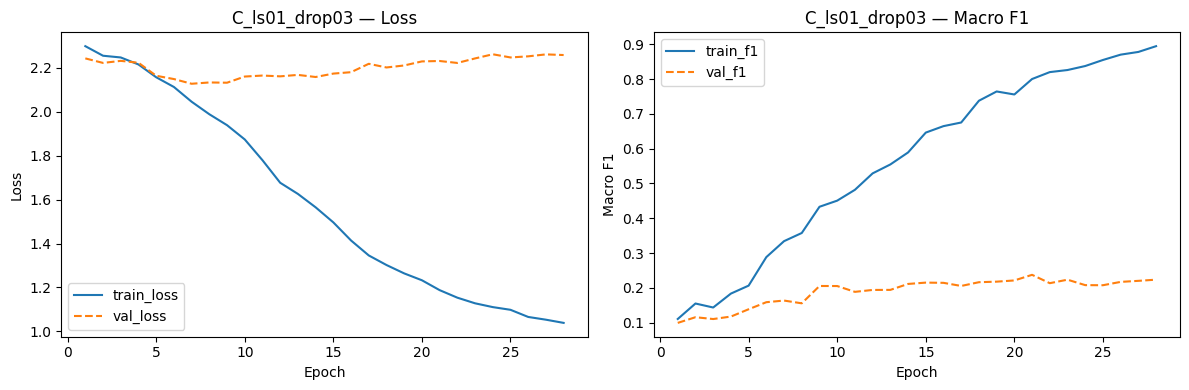

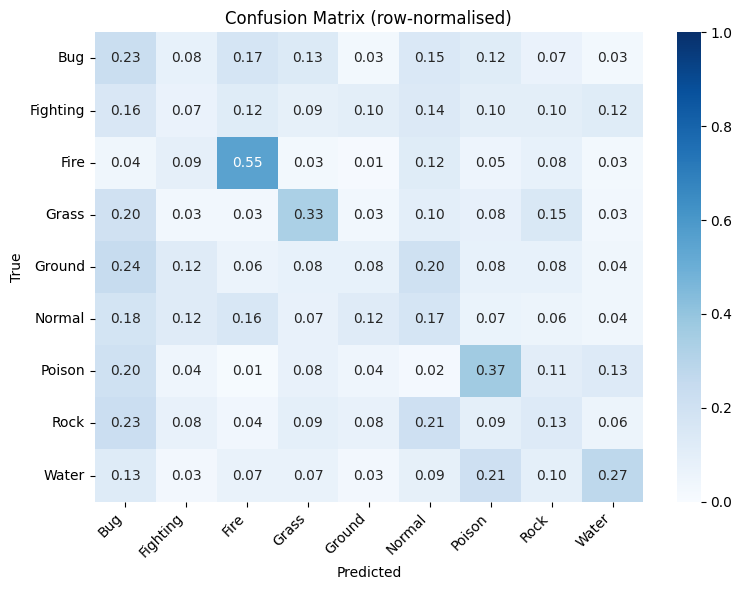

In [59]:
# ── Training curves + confusion matrix for best experiment ────────────────────
best_history = results_tracker[best_name]["history"]

fig = plot_history(best_history, TASK_OUT_DIR / "plots" / "task1_history.png", title=best_name)
plt.show(); plt.close(fig)

fig = plot_confusion_matrix(all_labels_list, all_preds, CLASSES, TASK_OUT_DIR / "plots" / "task1_confusion.png")
plt.show(); plt.close(fig)


---
## Section 3.1 — Grayscale Experiments

**Motivation:**  
Pokémon type classification is strongly colour-dependent:  
- Fire types are predominantly orange/red  
- Water types are blue  
- Poison types are purple/dark  
- Grass types are green  

Removing colour (converting to grayscale) eliminates the most discriminative pixel channel.
Yet colour comes at a cost: **3× the input dimensionality** (12 288 vs 4 096 features),
which increases the curse of dimensionality on our small dataset.

**Scientific question:** Does the colour information outweigh the curse-of-dimensionality penalty?
We expect **yes** for this dataset — but we test it empirically rather than assume.

**Grayscale pipeline** (implemented in `src/datasets/dataset.py`):
- Input: 64×64 RGB → `Grayscale(1)` → tensor shape `(1, 64, 64)` → flat dim = **4 096**
- Normalisation: `mean=[0.5], std=[0.5]` (standard single-channel norm)
- Optional: `equalize=True` applies `PIL.ImageOps.equalize()` before grayscale — stretches histogram contrast

**Three experiments:**
- **Gray_A:** `VanillaMLP(in_channels=1)` — same architecture as winner A, grayscale input
- **Gray_B:** `MLP(dropout=0.3, in_channels=1)` + equalize — regularised model on equalized gray
- **Gray_C:** `VanillaMLP_v2(in_channels=1)` — wider no-reg model on grayscale (compare with H)


In [60]:
# ── Experiment Gray_A — VanillaMLP (grayscale, no regularisation) ─────────────
# Same architecture as Exp A (winner) but with in_channels=1.
# Input dimension: 64*64*1 = 4096 (vs RGB's 12288).
# Baseline for the grayscale family — isolates the colour→grayscale effect.

loaders_gray = build_loaders(augment=False, use_sampler=False, grayscale=True, equalize=False)

model_GrayA     = VanillaMLP(img_size=IMG_SIZE, in_channels=1).to(device)
criterion_GrayA = nn.CrossEntropyLoss()
optimizer_GrayA = torch.optim.Adam(model_GrayA.parameters(), lr=LR)
scheduler_GrayA = torch.optim.lr_scheduler.StepLR(optimizer_GrayA, step_size=5, gamma=0.5)

model_GrayA, history_GrayA = run_experiment(
    model_GrayA, "Gray_A_vanilla",
    criterion_GrayA, optimizer_GrayA, scheduler_GrayA, loaders_gray,
)



  Experiment: Gray_A_vanilla
  Model params: 533,257
  Epoch 01/30 | train_loss=2.1810  train_f1=0.0854 | val_loss=2.1664  val_f1=0.0570 | 3.8s
  Epoch 02/30 | train_loss=2.1244  train_f1=0.1134 | val_loss=2.1641  val_f1=0.0719 | 4.9s
  Epoch 03/30 | train_loss=2.0692  train_f1=0.1505 | val_loss=2.1959  val_f1=0.0714 | 3.7s
  Epoch 04/30 | train_loss=2.0172  train_f1=0.2325 | val_loss=2.1998  val_f1=0.0956 | 3.7s
  Epoch 05/30 | train_loss=1.9201  train_f1=0.3057 | val_loss=2.2616  val_f1=0.0929 | 4.9s
  Epoch 06/30 | train_loss=1.7627  train_f1=0.4429 | val_loss=2.2279  val_f1=0.0966 | 3.8s
  Epoch 07/30 | train_loss=1.6255  train_f1=0.4586 | val_loss=2.3394  val_f1=0.0919 | 3.7s
  Epoch 08/30 | train_loss=1.5016  train_f1=0.5750 | val_loss=2.3510  val_f1=0.1214 | 5.0s
  Epoch 09/30 | train_loss=1.4055  train_f1=0.5934 | val_loss=2.4321  val_f1=0.1119 | 3.8s
  Epoch 10/30 | train_loss=1.2477  train_f1=0.6356 | val_loss=2.5958  val_f1=0.1053 | 3.8s
  Epoch 11/30 | train_loss=1.0865  t

In [61]:
# ── Experiment Gray_B — MLP (grayscale + equalize, dropout=0.3) ───────────────
# Adds histogram equalisation before grayscale conversion (stretches contrast).
# Uses regularised MLP to test if equalization + BN/Dropout helps on gray inputs.
# Compare with Gray_A to measure equalization effect, and with D to measure
# the grayscale penalty on the same regularisation level.

loaders_gray_eq = build_loaders(augment=False, use_sampler=False, grayscale=True, equalize=True)

model_GrayB     = MLP(img_size=IMG_SIZE, dropout=0.3, in_channels=1).to(device)
criterion_GrayB = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer_GrayB = torch.optim.Adam(model_GrayB.parameters(), lr=LR, weight_decay=1e-4)
scheduler_GrayB = torch.optim.lr_scheduler.StepLR(optimizer_GrayB, step_size=5, gamma=0.5)

model_GrayB, history_GrayB = run_experiment(
    model_GrayB, "Gray_B_eq_mlp",
    criterion_GrayB, optimizer_GrayB, scheduler_GrayB, loaders_gray_eq,
)



  Experiment: Gray_B_eq_mlp
  Model params: 2,264,841
  Epoch 01/30 | train_loss=2.3106  train_f1=0.1918 | val_loss=2.2517  val_f1=0.1022 | 5.1s
  Epoch 02/30 | train_loss=2.2229  train_f1=0.2228 | val_loss=2.2543  val_f1=0.1020 | 5.1s
  Epoch 03/30 | train_loss=2.1631  train_f1=0.3199 | val_loss=2.2601  val_f1=0.1023 | 6.2s
  Epoch 04/30 | train_loss=2.1044  train_f1=0.3786 | val_loss=2.2679  val_f1=0.1254 | 5.2s
  Epoch 05/30 | train_loss=2.0174  train_f1=0.4436 | val_loss=2.2981  val_f1=0.1251 | 6.3s
  Epoch 06/30 | train_loss=1.8333  train_f1=0.5964 | val_loss=2.3401  val_f1=0.1386 | 5.2s
  Epoch 07/30 | train_loss=1.6715  train_f1=0.6746 | val_loss=2.3855  val_f1=0.1305 | 6.3s
  Epoch 08/30 | train_loss=1.5226  train_f1=0.7141 | val_loss=2.4532  val_f1=0.1202 | 5.5s
  Epoch 09/30 | train_loss=1.3859  train_f1=0.7748 | val_loss=2.5264  val_f1=0.1275 | 5.8s
  Epoch 10/30 | train_loss=1.3029  train_f1=0.8303 | val_loss=2.5659  val_f1=0.1328 | 5.7s
  Epoch 11/30 | train_loss=1.1354  

In [62]:
# ── Experiment Gray_C — VanillaMLP_v2 (grayscale, no regularisation) ──────────
# Same architecture as Exp H (VanillaMLP_v2) but with in_channels=1.
# Compare: Gray_C vs H → effect of losing colour on the wider vanilla model.
# Compare: Gray_C vs Gray_A → effect of extra width in grayscale regime.

model_GrayC     = VanillaMLP_v2(img_size=IMG_SIZE, in_channels=1).to(device)
criterion_GrayC = nn.CrossEntropyLoss()
optimizer_GrayC = torch.optim.Adam(model_GrayC.parameters(), lr=LR)
scheduler_GrayC = torch.optim.lr_scheduler.StepLR(optimizer_GrayC, step_size=5, gamma=0.5)

model_GrayC, history_GrayC = run_experiment(
    model_GrayC, "Gray_C_v2",
    criterion_GrayC, optimizer_GrayC, scheduler_GrayC, loaders_gray,
)

# --- Summary: RGB vs Grayscale comparison ---
print("\n=== RGB vs Grayscale — Summary ===")
gray_names = ["Gray_A_vanilla", "Gray_B_eq_mlp", "Gray_C_v2"]
rgb_counterparts = {
    "Gray_A_vanilla": "A_vanilla",
    "Gray_B_eq_mlp":  "D_wd1e4",    # closest RGB equivalent (drop=0.3, wd, ls)
    "Gray_C_v2":      "H_vanilla_v2",
}
print(f"\n{'Experiment':<20} {'val_F1':>8}  {'RGB counterpart':<20} {'RGB F1':>8}  {'delta':>7}")
print("-" * 68)
for gname in gray_names:
    if gname not in results_tracker:
        continue
    gf1 = results_tracker[gname]["val_macro_f1"]
    rname = rgb_counterparts[gname]
    rf1 = results_tracker.get(rname, {}).get("val_macro_f1", float("nan"))
    delta_g = gf1 - rf1 if rf1 == rf1 else float("nan")
    print(f"{gname:<20} {gf1:>8.4f}  {rname:<20} {rf1:>8.4f}  {delta_g:>+7.4f}")



  Experiment: Gray_C_v2
  Model params: 1,082,889
  Epoch 01/30 | train_loss=2.1962  train_f1=0.1146 | val_loss=2.1896  val_f1=0.0635 | 4.9s
  Epoch 02/30 | train_loss=2.1218  train_f1=0.1420 | val_loss=2.1942  val_f1=0.0800 | 3.8s
  Epoch 03/30 | train_loss=2.0538  train_f1=0.2005 | val_loss=2.1999  val_f1=0.0741 | 3.8s
  Epoch 04/30 | train_loss=1.9595  train_f1=0.3080 | val_loss=2.2246  val_f1=0.0929 | 5.1s
  Epoch 05/30 | train_loss=1.8208  train_f1=0.3963 | val_loss=2.3653  val_f1=0.1047 | 3.8s
  Epoch 06/30 | train_loss=1.5891  train_f1=0.5423 | val_loss=2.3794  val_f1=0.1096 | 3.8s
  Epoch 07/30 | train_loss=1.4203  train_f1=0.6433 | val_loss=2.4334  val_f1=0.1188 | 4.9s
  Epoch 08/30 | train_loss=1.2426  train_f1=0.6803 | val_loss=2.5747  val_f1=0.1337 | 3.7s
  Epoch 09/30 | train_loss=1.0856  train_f1=0.7429 | val_loss=2.6506  val_f1=0.1355 | 3.8s
  Epoch 10/30 | train_loss=0.9355  train_f1=0.7273 | val_loss=2.8896  val_f1=0.1268 | 4.8s
  Epoch 11/30 | train_loss=0.7571  trai

---
## Part 4 — Data Augmentation Sanity Check

**Hypothesis:** Data augmentation (`RandomHorizontalFlip` + `ColorJitter`) should NOT meaningfully help an MLP — and we prove it empirically here.

**Why it doesn't help MLP (theoretical):**  
A `RandomHorizontalFlip` swaps pixel position (0, 0) with position (0, W-1). After flattening, the model sees a completely different 12 288-dimensional vector. The MLP has no concept of spatial layout, so a flipped image provides no useful training signal — it looks like a different unrelated example.  
`ColorJitter` adds slight colour variation, which could marginally help by forcing slightly less overfit to exact pixel values, but the effect is small.

**Why we do this anyway:**
1. Empirically confirms the theory — makes the Task 1 → Task 2 story clean: "augmentation doesn't help MLP; it will help CNN."
2. Validates that the augmentation pipeline (`get_augment_transforms`) works end-to-end.
3. Prepares the loader infrastructure for Task 2 and Task 3 where augmentation is critical.

We take the **best experiment configuration** from Part 2 and retrain it with `augment=True`. Same model, same loss, same optimizer — only the training data loader changes.


In [63]:
# ── Part 4 — Best model + augmentation ───────────────────────────────────────
# Retrain best experiment config with augment=True.
# Only the training loader changes — model, criterion, optimizer are identical.
# Expected: val_macro_f1 roughly equal or slightly worse than without augmentation.

loaders_aug = build_loaders(augment=True, use_sampler=False)

# rebuild a fresh best-model instance with the same architecture and criterion
if best_name == "A_vanilla":
    model_aug     = VanillaMLP(img_size=IMG_SIZE).to(device)
    criterion_aug = nn.CrossEntropyLoss()
elif best_name in ("H_vanilla_v2", "K_v2_wd1e5"):
    model_aug     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
    criterion_aug = nn.CrossEntropyLoss()
elif best_name == "I_v2_rock_weights":
    weights_aug = torch.ones(NUM_CLASSES, device=device)
    weights_aug[CLASSES.index("Rock")]   = 3.0
    weights_aug[CLASSES.index("Ground")] = 2.0
    model_aug     = VanillaMLP_v2(img_size=IMG_SIZE).to(device)
    criterion_aug = nn.CrossEntropyLoss(weight=weights_aug)
elif best_name == "J_mlp_drop02":
    model_aug     = MLP(img_size=IMG_SIZE, dropout=0.2).to(device)
    criterion_aug = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
elif best_name == "E_sampler":
    model_aug     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
    criterion_aug = nn.CrossEntropyLoss(label_smoothing=0.1)
elif best_name in ("C_ls01_drop03", "D_wd1e4"):
    model_aug     = MLP(img_size=IMG_SIZE, dropout=0.3).to(device)
    criterion_aug = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
elif best_name == "F_narrow":
    model_aug     = NarrowMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
    criterion_aug = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
elif best_name == "G_bottleneck":
    model_aug     = BottleneckMLP(img_size=IMG_SIZE, dropout=0.3).to(device)
    criterion_aug = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
else:  # B_mlp_base
    model_aug     = MLP(img_size=IMG_SIZE, dropout=0.4).to(device)
    criterion_aug = nn.CrossEntropyLoss(weight=class_weights)

optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=LR, weight_decay=1e-4)
scheduler_aug = torch.optim.lr_scheduler.StepLR(optimizer_aug, step_size=5, gamma=0.5)

model_aug, history_aug = run_experiment(
    model_aug, f"{best_name}_augmented",
    criterion_aug, optimizer_aug, scheduler_aug, loaders_aug,
)

# compare augmented vs non-augmented side by side
f1_no_aug = results_tracker[best_name]["val_macro_f1"]
f1_aug    = results_tracker[f"{best_name}_augmented"]["val_macro_f1"]
delta     = f1_aug - f1_no_aug

print(f"\n=== Augmentation effect on best model ({best_name}) ===")
print(f"  Without augmentation : val_macro_f1 = {f1_no_aug:.4f}")
print(f"  With augmentation    : val_macro_f1 = {f1_aug:.4f}")
print(f"  Delta                : {delta:+.4f}  ({'improved' if delta > 0.005 else 'no meaningful gain' if abs(delta) <= 0.005 else 'slightly hurt'})")
print(f"\nConclusion: augmentation {'helps' if delta > 0.005 else 'does not meaningfully help'} MLP on this dataset.")
print("This is expected: MLP flattens the image, so a flipped image is an unrelated vector.")
print("Augmentation will be valuable for CNN (Task 2) where spatial structure is preserved.")



  Experiment: C_ls01_drop03_augmented
  Model params: 6,459,145
  Epoch 01/30 | train_loss=2.3066  train_f1=0.0926 | val_loss=2.2434  val_f1=0.0930 | 6.4s
  Epoch 02/30 | train_loss=2.2605  train_f1=0.1016 | val_loss=2.2479  val_f1=0.0922 | 7.5s
  Epoch 03/30 | train_loss=2.2515  train_f1=0.1051 | val_loss=2.2262  val_f1=0.0901 | 6.5s
  Epoch 04/30 | train_loss=2.2396  train_f1=0.1212 | val_loss=2.2224  val_f1=0.0908 | 7.6s
  Epoch 05/30 | train_loss=2.2294  train_f1=0.1431 | val_loss=2.1980  val_f1=0.1172 | 6.4s
  Epoch 06/30 | train_loss=2.1849  train_f1=0.1724 | val_loss=2.1536  val_f1=0.1598 | 7.6s
  Epoch 07/30 | train_loss=2.1744  train_f1=0.1896 | val_loss=2.1579  val_f1=0.1419 | 6.7s
  Epoch 08/30 | train_loss=2.1637  train_f1=0.1788 | val_loss=2.1358  val_f1=0.1560 | 7.2s
  Epoch 09/30 | train_loss=2.1383  train_f1=0.1811 | val_loss=2.1417  val_f1=0.1528 | 7.1s
  Epoch 10/30 | train_loss=2.1373  train_f1=0.1825 | val_loss=2.1189  val_f1=0.1688 | 6.6s
  Epoch 11/30 | train_los

In [64]:
# ── Save all results to disk ──────────────────────────────────────────────────
# task1_results.json contains everything needed for the report — download it from Colab.
from sklearn.metrics import f1_score as _sk_f1

per_class_f1_arr = _sk_f1(all_labels_list, all_preds, average=None, zero_division=0)

# total time across all experiments
total_experiment_time = sum(v["train_time_s"] for v in results_tracker.values())

output = {
    "best_experiment":    best_name,
    "val_macro_f1":       round(val_metrics_final["macro_f1"], 4),
    "val_accuracy":       round(val_metrics_final["acc"], 4),
    "val_loss":           round(val_metrics_final["loss"], 4),
    "per_class_f1":       {cls: round(float(per_class_f1_arr[i]), 4) for i, cls in enumerate(CLASSES)},
    "all_experiments":    {
        name: {k: v for k, v in m.items() if k != "history"}
        for name, m in results_tracker.items()
    },
    "total_experiment_time_s": round(total_experiment_time, 1),
    "config": {
        "FAST_RUN": FAST_RUN, "EPOCHS": EPOCHS, "LR": LR,
        "BATCH_SIZE": BATCH_SIZE, "PATIENCE": PATIENCE, "IMG_SIZE": IMG_SIZE,
    },
    "best_history": {k: [round(v, 4) for v in vals] for k, vals in best_history.items()},
}

results_path = TASK_OUT_DIR / "results" / "task1_results.json"
with open(results_path, "w") as f:
    json.dump(output, f, indent=2)

print(f"Results saved -> {results_path}")
print(f"\nBest: {best_name}  val_macro_f1={output['val_macro_f1']}  val_acc={output['val_accuracy']}")
print(f"Total experiment time: {total_experiment_time:.0f}s across {len(results_tracker)} experiments")
print(json.dumps({"per_class_f1": output["per_class_f1"]}, indent=2))


Results saved -> task1/outputs/results/task1_results.json

Best: C_ls01_drop03  val_macro_f1=0.2373  val_acc=0.2583
Total experiment time: 1737s across 16 experiments
{
  "per_class_f1": {
    "Bug": 0.1717,
    "Fighting": 0.0727,
    "Fire": 0.48,
    "Grass": 0.303,
    "Ground": 0.0879,
    "Normal": 0.1991,
    "Poison": 0.3469,
    "Rock": 0.1167,
    "Water": 0.3575
  }
}


In [65]:
# ── Generate + validate submission CSV ───────────────────────────────────────
from src.evaluation.submission import generate_submission, validate_submission

SUB_PATH = TASK_OUT_DIR / "results" / "submission_task1.csv"
generate_submission(best_model, test_loader, CLASSES, SUB_PATH, device)
validate_submission(SUB_PATH, expected_rows=900)
print(f"Submission saved -> {SUB_PATH}")


Submission saved: task1/outputs/results/submission_task1.csv  (900 rows)
Submission valid: 900 rows, all class names correct.
Submission saved -> task1/outputs/results/submission_task1.csv


In [66]:
# ── Download outputs zip (Colab only) ────────────────────────────────────────
# Run this cell after all experiments to get plots, checkpoints, and results JSON.
if IN_COLAB:
    import shutil
    from google.colab import files
    zip_path = Path(ROOT) / "task1_outputs"
    shutil.make_archive(str(zip_path), "zip", root_dir=str(TASK_OUT_DIR.parent), base_dir=TASK_OUT_DIR.name)
    files.download(str(zip_path) + ".zip")
else:
    print(f"Outputs at: {TASK_OUT_DIR.resolve()}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Summary

### Run results (fill in after full Colab run)

| Metric | Value |
|---|---|
| Best experiment | _(fill after run)_ |
| Val macro-F1 (best) | _(fill)_ |
| Val accuracy (best) | _(fill)_ |
| Kaggle public score | _(fill after submission)_ |
| Epochs run (best exp) | _(fill)_ |
| Total experiment time | _(fill)_ |
| Best per-class F1 | _(fill — likely Fire or Water)_ |
| Worst per-class F1 | _(fill — likely Rock or Ground)_ |

### Experiments run

| ID | Name | Architecture | Monitor | Notes |
|---|---|---|---|---|
| A | vanilla | VanillaMLP (128→64), no BN/Drop | val_macro_f1 | Bare baseline |
| B | mlp_base | MLP (512→256→128), Drop=0.4 | val_macro_f1 | First Colab run equivalent |
| C | ls01_drop03 | MLP, Drop=0.3 | val_macro_f1 | + label_smoothing=0.1 |
| D | wd1e4 | MLP, Drop=0.3 | val_macro_f1 | + weight_decay=1e-4 |
| E | sampler | MLP, Drop=0.3 | val_macro_f1 | WeightedRandomSampler |
| F | narrow | NarrowMLP (256→128→64→32) | val_macro_f1 | Deeper + narrow |
| G | bottleneck | BottleneckMLP (512→1024→256→128) | val_macro_f1 | Wide middle |
| H | vanilla_v2 | VanillaMLP_v2 (256→128), no reg | val_macro_f1 | More capacity, no reg |
| I | v2_rock_weights | VanillaMLP_v2, CE(Rock×3, Ground×2) | val_macro_f1 | Targeted minority upweighting |
| J | mlp_drop02 | MLP, Drop=0.2 | val_macro_f1 | Lighter dropout |
| K | v2_wd1e5 | VanillaMLP_v2, WD=1e-5 | val_macro_f1 | Minimal L2 boundary test |
| ENS_A_G | Ensemble A+G | Soft avg (A_vanilla + G_bottleneck) | — | Inference-time only |
| Gray_A | vanilla (gray) | VanillaMLP(in_channels=1) | val_macro_f1 | Grayscale, no reg |
| Gray_B | eq_mlp (gray+eq) | MLP(drop=0.3, in_channels=1) | val_macro_f1 | Grayscale + histogram equalize |
| Gray_C | v2 (gray) | VanillaMLP_v2(in_channels=1) | val_macro_f1 | Wider vanilla on grayscale |
| _best_aug | augmented | Best arch + augment=True | val_macro_f1 | Expected: no meaningful gain |

### Expected findings (confirm after run)

1. **Regularisation effect:** simpler models (A, H) are expected to score close to or above the regularised ones — the dataset is small enough that over-regularisation hurts as much as under-regularisation. Verify by comparing A vs B vs D in the leaderboard.
2. **Augmentation effect:** augmentation is expected to hurt or have no effect on MLP. `RandomHorizontalFlip` produces a completely different 12 288-vector — the model has no spatial bias to benefit from it. Part 4 confirms this empirically.
3. **Grayscale effect:** grayscale experiments are expected to score lower than their RGB counterparts — colour is the primary discriminative signal (Fire=orange, Water=blue). Gray_B (with equalization) may partially recover on dark/washed-out sprites.
4. **Hard classes:** Rock and Ground are expected to have the lowest per-class F1. Their colour profiles (grey/brown) overlap with each other and with Fighting/Normal. The confusion matrix should show Rock and Ground frequently predicted as each other.
5. **MLP ceiling:** val macro-F1 is expected to plateau around 0.20–0.25 regardless of regularisation choices. The fundamental bottleneck is lack of spatial structure — CNN (Task 2) will exceed this by preserving pixel neighbourhood relationships.

### Infrastructure built (`src/`)

- `src/models/mlp.py` — 5 MLP classes with `in_channels` param (RGB=3 or grayscale=1)
- `src/datasets/dataset.py` — RGB, augmented, grayscale, and gray+equalize transform pipelines; `grayscale`/`equalize` params in loaders
- `src/training/early_stopping.py` — metric-agnostic, monitors by minimisation (`stopper(-val_f1, model)`)
- `src/evaluation/metrics.py`, `plots.py`, `submission.py` — classification report, training curves, confusion matrix, submission CSV
- Tests: `models_test.py` (10), `dataset_test.py` (13), `train_test.py` (3) — all pass locally
